# 🎲 Naive Bayes — Fast Probabilistic Classifiers From Bayes' Theorem

> **What you'll learn:** how Bayes' theorem plus one bold "independence" assumption gives a classifier that trains by counting, why it ranks well even when its probabilities are badly overconfident, the five scikit-learn variants (Gaussian, Multinomial, Bernoulli, Complement, Categorical) and when to use each, smoothing and log-probabilities, calibration with reliability curves, and streaming with `partial_fit`. You will build Gaussian and Bernoulli Naive Bayes from scratch and match scikit-learn exactly, then build a spam filter.

| | |
|---|---|
| **Difficulty** | 🟢 Beginner → 🟡 Intermediate → 🔴 Interview depth |
| **Time** | ~4 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [K-Nearest Neighbors](05_K_Nearest_Neighbors.ipynb) (classification workflow, probabilities from neighbours) · [Statistics & Probability](../01_Core_Scientific_Computing/05_Statistics_and_Probability.ipynb) (conditional probability, Bayes' theorem, the normal distribution) |
| **Tested with** | Python 3.12 · scikit-learn 1.9 · numpy 2.5 · pandas 3.0 · scipy 1.18 |
| **Interview relevance** | ⭐⭐⭐ High — "why is it called naive?", Laplace smoothing, generative vs discriminative, "why does it work if the assumption is wrong?", calibration, "implement Naive Bayes from scratch", spam-filter design |

## 🤔 What Is Naive Bayes?

Imagine sorting your post. A letter arrives with the words **"WINNER"**, **"free"** and **"claim now"** on the envelope. You think:

1. *Before looking:* about 1 in 7 letters I get is junk (the **prior**).
2. *Each clue:* "WINNER" shows up in lots of junk and almost never in real letters; so does "claim now" (the **likelihoods**).
3. *Combine:* multiply the prior by each clue's likelihood, for "junk" and for "real", and pick the bigger one (the **posterior**).

That's **Naive Bayes**. It uses **Bayes' theorem** to turn "how often does this clue appear in each class?" into "how likely is each class given these clues?"

```
P(class | clues)  ∝  P(class) × P(clue₁ | class) × P(clue₂ | class) × ... × P(clueₙ | class)
     posterior          prior            likelihood of each clue, assumed independent
```

- **Naive** = it assumes the clues are **independent once you know the class** ("WINNER" and "free" don't influence each other inside junk mail). That's almost never exactly true, which is why it's called naive.
- **Generative model** = it learns how each class *generates* features, $P(x \mid y)$, then flips it with Bayes' rule. (Logistic regression is *discriminative*: it learns $P(y \mid x)$ directly.)
- **Training = counting** (or computing means and variances). No gradient descent, one pass over the data.

## 🎯 Why It Matters

- **The fastest strong baseline.** It trains in one pass, in milliseconds on thousands of documents, and is often surprisingly close to much heavier models on text. Build it first; make everything else beat it.
- **Spam filtering and text classification** made Naive Bayes famous (email spam filters, document routing, sentiment, language ID), and it is still used where speed, tiny models and online updates matter.
- **Streaming and huge data.** Counts can be updated incrementally with `partial_fit`, so the model learns from data that never fits in memory.
- **Probability literacy.** It is the cleanest example of Bayes' theorem, priors, likelihoods, smoothing, log-space arithmetic and calibration — ideas you need for LLM evaluation, A/B tests and every probabilistic model.
- **In interviews** it's a classic: *"why is it called naive?"*, *"what's Laplace smoothing for?"*, *"why does it work if features aren't independent?"*, *"generative vs discriminative?"*, *"are its probabilities trustworthy?"*, *"implement it from scratch"* and *"design a spam filter"*.

## 🃏 Algorithm Card

| | Naive Bayes |
|---|---|
| **Learning type** | Supervised, probabilistic, **generative**, parametric |
| **Tasks** | Classification (binary and multi-class); especially text, spam, document routing, quick baselines |
| **Model / objective** | $\hat y = \arg\max_c \big[\log P(c) + \sum_j \log P(x_j \mid c)\big]$. Parameters are maximum-likelihood (or smoothed) estimates: class frequencies plus per-feature distributions (Gaussian means/variances, or smoothed counts) |
| **Key hyperparameters (typical ranges)** | `alpha` smoothing for Multinomial/Bernoulli/Complement/Categorical (0.01–1, log scale), `var_smoothing` for Gaussian (1e-9–1e-1), `fit_prior` / `class_prior`, `binarize` threshold for Bernoulli, `norm` for Complement |
| **Needs feature scaling?** | No (Gaussian NB models each feature's own scale). Count-based variants need **non-negative** features (counts, TF-IDF, one-hot) — never standardized values |
| **Handles missing values / categoricals?** | Missing: no in scikit-learn (impute, or add a "missing" category). Categoricals: yes with `CategoricalNB` (ordinal-encode first) or one-hot + `BernoulliNB` |
| **Training & prediction complexity** | Fit O(n·d) — one pass; `partial_fit` for streaming. Predict O(d·C) per sample; sparse text only touches the words present. Model size O(d·C) |
| **Interpretability** | High: per-class feature log-probabilities show exactly which words/values push each class |
| **Strengths** | Extremely fast, tiny, works with little data and very many features, naturally multi-class, incremental updates, robust baseline for text |
| **Weaknesses** | Independence assumption: correlated features are double-counted → **overconfident, poorly calibrated probabilities**; linear-ish boundaries; usually beaten by tuned logistic regression / linear SVM / boosting with enough data |
| **Use it when** | Text or count data, tiny training sets, very high dimensions, need millisecond training or online learning, a baseline in minutes |
| **Avoid it when** | Probabilities must be accurate (calibrate first), strongly correlated or interacting features dominate, you have lots of data and time for a discriminative model |
| **Best libraries** | scikit-learn (`GaussianNB`, `MultinomialNB`, `BernoulliNB`, `ComplementNB`, `CategoricalNB`, `CalibratedClassifierCV`, `HashingVectorizer`); Spark MLlib `NaiveBayes` for distributed data |

## ✅ By the End You Can

- [ ] Apply Bayes' theorem by hand and explain exactly what the "naive" independence assumption is
- [ ] Choose between Gaussian, Multinomial, Bernoulli, Complement and Categorical Naive Bayes for a given dataset
- [ ] Explain and tune Laplace/Lidstone smoothing, and compute everything in log space to avoid underflow
- [ ] Show that Naive Bayes ranks well while its probabilities are overconfident, and fix them with calibration
- [ ] Train at scale and on streams with `partial_fit`, and compare fairly against logistic regression
- [ ] Implement Gaussian and Bernoulli Naive Bayes from scratch and match scikit-learn's `predict_log_proba`

## 📋 Table of Contents

1. [Bayes' Theorem Recap](#1.-Bayes'-Theorem-Recap-🟢)
2. [The Naive Independence Assumption](#2.-The-Naive-Independence-Assumption-🟢)
3. [Log-Probabilities: Avoiding Underflow](#3.-Log-Probabilities:-Avoiding-Underflow-🟢)
4. [Gaussian Naive Bayes](#4.-Gaussian-Naive-Bayes-🟢)
5. [Multinomial Naive Bayes for Counts](#5.-Multinomial-Naive-Bayes-for-Counts-🟢)
6. [Smoothing and the Zero-Frequency Problem](#6.-Smoothing-and-the-Zero-Frequency-Problem-🟡)
7. [Bernoulli Naive Bayes for Binary Features](#7.-Bernoulli-Naive-Bayes-for-Binary-Features-🟡)
8. [Complement Naive Bayes for Imbalanced Text](#8.-Complement-Naive-Bayes-for-Imbalanced-Text-🟡)
9. [Categorical Naive Bayes](#9.-Categorical-Naive-Bayes-🟡)
10. [Why "Naive" Still Works: Good Rankings, Poor Probabilities](#10.-Why-"Naive"-Still-Works:-Good-Rankings,-Poor-Probabilities-🔴)
11. [Calibration: Reliability Curves and CalibratedClassifierCV](#11.-Calibration:-Reliability-Curves-and-CalibratedClassifierCV-🔴)
12. [Speed at Scale and Streaming With partial_fit](#12.-Speed-at-Scale-and-Streaming-With-partial_fit-🟡)
13. [A Fair Head-to-Head Comparison](#13.-A-Fair-Head-to-Head-Comparison-🟡)
- [🃏 Algorithm Card](#🃏-Algorithm-Card) · [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-SMS-Spam-Filter-Showdown) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a library is missing, uncomment the `%pip` line, run it once, then restart the kernel.

The `check()` helper gives you instant feedback on exercises: **✅** correct, **⏳** not attempted yet, **❌** wrong (with a hint).

**Data (all real):**
- **SMS Spam Collection** (UCI, ~200 KB): 5,574 real text messages labelled spam/ham, downloaded once to `_outputs/sms_spam/`.
- **20 Newsgroups** (~14 MB): ~18,800 newsgroup posts in 20 topics, cached in `_outputs/sklearn_data/`.
- **Mushroom** (OpenML, <1 MB): 22 categorical descriptions of 8,124 mushrooms, edible or poisonous.
- **Breast cancer, wine, digits**: bundled with scikit-learn.

In [1]:
# %pip install -q "scikit-learn>=1.6" "pandas>=2.2" "scipy>=1.11" matplotlib

import gc
import io
import sys
import time
import urllib.request
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from matplotlib.colors import ListedColormap
from scipy import sparse
from scipy.special import logsumexp
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.datasets import fetch_20newsgroups, fetch_openml, load_breast_cancer, load_digits, load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, HashingVectorizer, TfidfVectorizer
from sklearn.frozen import FrozenEstimator
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    f1_score,
    log_loss,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    cross_val_score,
    cross_validate,
    train_test_split,
    validation_curve,
)
from sklearn.naive_bayes import BernoulliNB, CategoricalNB, ComplementNB, GaussianNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.svm import LinearSVC

print(f"Python {sys.version.split()[0]} | scikit-learn {sklearn.__version__} | numpy {np.__version__} | "
      f"pandas {pd.__version__} | scipy {scipy.__version__}")

SEED = 42
rng = np.random.default_rng(SEED)
pd.set_option("display.precision", 4)
OUTPUT_DIR = Path("_outputs")              # files we write go here (ignored by git)
DATA_HOME = OUTPUT_DIR / "sklearn_data"    # scikit-learn download cache
DATA_HOME.mkdir(parents=True, exist_ok=True)


def check(name, got, expected, hint="", rtol=1e-4, atol=1e-6):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (bool, np.bool_, str)):
        ok = got == expected
    else:
        try:
            g, e = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        except (TypeError, ValueError):
            raise AssertionError(f"❌ {name}: expected a number/array, got {type(got).__name__}. {hint}")
        if g.shape != e.shape:
            raise AssertionError(f"❌ {name}: shape {g.shape}, expected {e.shape}. {hint}")
        ok = np.allclose(g, e, rtol=rtol, atol=atol)
    assert ok, f"❌ {name}: not quite. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | scikit-learn 1.9.1 | numpy 2.5.3 | pandas 3.0.5 | scipy 1.18.1


In [2]:
SMS_FILE = OUTPUT_DIR / "sms_spam" / "SMSSpamCollection"
if not SMS_FILE.exists():
    SMS_FILE.parent.mkdir(parents=True, exist_ok=True)
    url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
    with urllib.request.urlopen(url, timeout=60) as response:
        zipfile.ZipFile(io.BytesIO(response.read())).extract("SMSSpamCollection", SMS_FILE.parent)
lines = SMS_FILE.read_text(encoding="utf-8").strip().split("\n")
sms_raw = pd.DataFrame([line.split("\t", 1) for line in lines], columns=["label", "text"])
sms = sms_raw.drop_duplicates(subset="text").reset_index(drop=True)          # exact duplicate messages would leak across splits
sms["spam"] = (sms["label"] == "spam").astype(int)
print(f"SMS: {len(sms_raw):,} messages, {len(sms_raw) - len(sms):,} exact duplicates removed → {len(sms):,} | "
      f"spam rate {sms['spam'].mean():.1%}")

# One split for the concept sections; the mini project uses the same split and touches its test part once at the end
sms_train, sms_test = train_test_split(sms, test_size=0.2, stratify=sms["spam"], random_state=SEED)
print(f"SMS train {len(sms_train):,} | test {len(sms_test):,}")

news_train = fetch_20newsgroups(subset="train", data_home=DATA_HOME, remove=("headers", "footers", "quotes"))
news_test = fetch_20newsgroups(subset="test", data_home=DATA_HOME, remove=("headers", "footers", "quotes"))
print(f"20 Newsgroups: train {len(news_train.data):,} | test {len(news_test.data):,} | {len(news_train.target_names)} topics")

SMS: 5,574 messages, 403 exact duplicates removed → 5,171 | spam rate 12.6%
SMS train 4,136 | test 1,035


20 Newsgroups: train 11,314 | test 7,532 | 20 topics


## 1. Bayes' Theorem Recap 🟢

For two events $A$ and $B$:

$$P(A \mid B) = \frac{P(B \mid A)\, P(A)}{P(B)}, \qquad P(B) = P(B \mid A)P(A) + P(B \mid \neg A)P(\neg A)$$

| Term | Name | Spam example |
|---|---|---|
| $P(A)$ | **prior** | fraction of messages that are spam, before reading |
| $P(B \mid A)$ | **likelihood** | how often spam contains the word "free" |
| $P(B)$ | **evidence** | how often any message contains "free" |
| $P(A \mid B)$ | **posterior** | chance a message is spam *given* it contains "free" |

Let's check on the real SMS training messages that Bayes' rule gives exactly the same answer as counting directly.

In [3]:
has_free = CountVectorizer(vocabulary=["free"], binary=True).fit_transform(sms_train["text"]).toarray().ravel().astype(bool)
is_spam = sms_train["spam"].to_numpy().astype(bool)

p_spam = is_spam.mean()                                  # prior
p_free_given_spam = has_free[is_spam].mean()             # likelihood
p_free = has_free.mean()                                 # evidence
posterior_bayes = p_free_given_spam * p_spam / p_free
posterior_counting = is_spam[has_free].mean()            # directly: among messages with "free", how many are spam?

print(f"P(spam) = {p_spam:.3f} | P('free' | spam) = {p_free_given_spam:.3f} | P('free') = {p_free:.3f}")
print(f"P(spam | 'free') by Bayes' rule = {posterior_bayes:.3f} | by direct counting = {posterior_counting:.3f}")
assert np.isclose(posterior_bayes, posterior_counting)
print(f"→ seeing 'free' raises the spam probability from {p_spam:.1%} to {posterior_bayes:.1%} ({posterior_bayes / p_spam:.1f}×)")

P(spam) = 0.126 | P('free' | spam) = 0.224 | P('free') = 0.038
P(spam | 'free') by Bayes' rule = 0.741 | by direct counting = 0.741
→ seeing 'free' raises the spam probability from 12.6% to 74.1% (5.9×)


### ✍️ Your Turn

A disease affects 1% of people. A test detects it 90% of the time (sensitivity) but also gives a positive result for 5% of healthy people. If someone tests positive, what is the probability they have the disease? Store it in `p_disease_given_positive`.

In [4]:
prior_disease, sensitivity, false_positive_rate = 0.01, 0.90, 0.05
p_disease_given_positive = None  # TODO: your code here
check("p_disease_given_positive", p_disease_given_positive, 0.1538462,
      hint="evidence = sensitivity*prior + false_positive_rate*(1 - prior); posterior = sensitivity*prior / evidence")

⏳ p_disease_given_positive: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
prior_disease, sensitivity, false_positive_rate = 0.01, 0.90, 0.05
evidence = sensitivity * prior_disease + false_positive_rate * (1 - prior_disease)
p_disease_given_positive = sensitivity * prior_disease / evidence
check("p_disease_given_positive", p_disease_given_positive, 0.1538462)
```

Only about 15%. The disease is rare, so false positives from the 99% healthy people outnumber the true positives. This **base-rate** effect is why priors matter.
</details>

> 💡 **Interview angle:** "A 99%-accurate test comes back positive for a rare condition — are you probably sick?" — not necessarily: the posterior depends on the prior. Walk through $P(D\mid +) = \frac{P(+\mid D)P(D)}{P(+)}$ with the base rate out loud.

## 2. The Naive Independence Assumption 🟢

For a classifier, $A$ is the class $y$ and $B$ is the whole feature vector $x = (x_1, \dots, x_d)$:

$$P(y \mid x) = \frac{P(y)\, P(x_1, \dots, x_d \mid y)}{P(x)}$$

The hard part is $P(x_1, \dots, x_d \mid y)$: with just 30 yes/no words there are $2^{30} \approx$ a billion combinations to estimate per class. Impossible from a few thousand messages.

**The naive assumption:** features are **conditionally independent given the class**, so the joint likelihood factorizes:

$$P(x_1, \dots, x_d \mid y) = \prod_{j=1}^{d} P(x_j \mid y) \quad\Rightarrow\quad \hat y = \arg\max_c \; P(c) \prod_{j=1}^{d} P(x_j \mid c)$$

Now each class needs only $d$ simple one-feature distributions (30 numbers instead of a billion). $P(x)$ is the same for every class, so we can ignore it for the argmax and just normalize at the end.

Let's classify a message by hand using two binary word features ("free", "call") and compare with `BernoulliNB`. With smoothing `alpha=1`, each probability is $P(\text{word} \mid c) = \frac{\text{count}(\text{word}, c) + 1}{n_c + 2}$ (Section 6 explains the +1 and +2).

In [5]:
two_words = CountVectorizer(vocabulary=["free", "call"], binary=True)
Xw_tr = two_words.fit_transform(sms_train["text"]).toarray()
yw_tr = sms_train["spam"].to_numpy()

message = np.array([1, 0])                              # contains "free", does not contain "call"
scores = {}
for c in (0, 1):
    in_class = Xw_tr[yw_tr == c]
    p_word = (in_class.sum(axis=0) + 1) / (len(in_class) + 2)     # P(word present | class), smoothed
    likelihood = np.prod(np.where(message == 1, p_word, 1 - p_word))   # absent words count too: P(absent) = 1 - p
    scores[c] = (yw_tr == c).mean() * likelihood
    print(f"class {c}: prior {(yw_tr == c).mean():.3f} × P(free|c) {p_word[0]:.3f} × P(no call|c) {1 - p_word[1]:.3f} "
          f"= {scores[c]:.5f}")
by_hand = scores[1] / (scores[0] + scores[1])
library = BernoulliNB(alpha=1.0).fit(Xw_tr, yw_tr).predict_proba(message[None, :])[0, 1]
print(f"\nP(spam | 'free', no 'call'): by hand {by_hand:.4f} | BernoulliNB {library:.4f}")
assert np.isclose(by_hand, library)

class 0: prior 0.874 × P(free|c) 0.012 × P(no call|c) 0.962 = 0.00976
class 1: prior 0.126 × P(free|c) 0.225 × P(no call|c) 0.571 = 0.01622

P(spam | 'free', no 'call'): by hand 0.6243 | BernoulliNB 0.6243


### ✍️ Your Turn

A filter estimated: $P(\text{spam}) = 0.2$, $P(\text{"free"} \mid \text{spam}) = 0.5$, $P(\text{"free"} \mid \text{ham}) = 0.02$, $P(\text{"win"} \mid \text{spam}) = 0.3$, $P(\text{"win"} \mid \text{ham}) = 0.01$. Using only these two word likelihoods (multinomial-style: ignore absent words), compute the naive-Bayes posterior $P(\text{spam} \mid \text{"free"}, \text{"win"})$.

In [6]:
p_spam_given_both = None  # TODO: your code here
check("p_spam_given_both", p_spam_given_both, 0.9946950, hint="spam score = 0.2*0.5*0.3; ham score = 0.8*0.02*0.01; normalize.")

⏳ p_spam_given_both: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
spam_score = 0.2 * 0.5 * 0.3
ham_score = 0.8 * 0.02 * 0.01
p_spam_given_both = spam_score / (spam_score + ham_score)
check("p_spam_given_both", p_spam_given_both, 0.9946950)
```

Two moderately suspicious words, multiplied together, give 99.5%. Notice how quickly independent evidence compounds — that's also why Naive Bayes becomes overconfident when the "independent" clues are really the same clue twice (Section 10).
</details>

> 💡 **Interview angle:** "Why is it called naive?" — it assumes features are conditionally independent given the class, $P(x\mid y) = \prod_j P(x_j\mid y)$. That turns an impossible joint estimate into d one-dimensional estimates, which is why it needs so little data, and why it double-counts correlated evidence.

## 3. Log-Probabilities: Avoiding Underflow 🟢

A 300-word post multiplies 300 probabilities, many around $10^{-4}$. The true product is around $10^{-1200}$, but the smallest positive `float64` is about $2 \times 10^{-308}$: the product **underflows to exactly 0.0** for every class, and the classifier can't tell them apart.

The fix: work with **sums of logs**. Since log is monotonic, $\arg\max$ is unchanged:

$$\log P(c \mid x) = \underbrace{\log P(c) + \sum_j \log P(x_j \mid c)}_{\text{joint log-likelihood } \ell_c} - \log \sum_{c'} e^{\ell_{c'}}$$

The last term normalizes, computed with the **log-sum-exp trick**: $\log\sum_c e^{\ell_c} = m + \log\sum_c e^{\ell_c - m}$ with $m = \max_c \ell_c$, so nothing overflows or underflows. scikit-learn stores `feature_log_prob_` and `class_log_prior_` and exposes `predict_log_proba` for exactly this reason.

In [7]:
news_counter = CountVectorizer(min_df=2).fit(news_train.data)
Xn_counts_tr = news_counter.transform(news_train.data)
mnb_news = MultinomialNB(alpha=0.1).fit(Xn_counts_tr, news_train.target)

doc_lengths = np.asarray(Xn_counts_tr.sum(axis=1)).ravel()
long_doc = int(np.argmax(doc_lengths))
row = Xn_counts_tr[long_doc]
word_ids, word_counts = row.indices, row.data

feature_probs = np.exp(mnb_news.feature_log_prob_[:, word_ids])          # (classes, words in this doc)
naive_products = np.prod(feature_probs ** word_counts, axis=1)            # multiply raw probabilities
log_joint = mnb_news.class_log_prior_ + mnb_news.feature_log_prob_[:, word_ids] @ word_counts

print(f"longest training post: {doc_lengths[long_doc]:,} tokens")
print(f"raw products for the 20 classes: {np.unique(naive_products)} → every class gets exactly 0.0")
print(f"log joint scores: best {log_joint.max():,.1f}, runner-up {np.sort(log_joint)[-2]:,.1f}")
manual_log_posterior = log_joint - logsumexp(log_joint)
assert np.allclose(manual_log_posterior, mnb_news.predict_log_proba(row)[0])
print(f"✅ log-space posterior matches predict_log_proba; predicted topic: {news_train.target_names[log_joint.argmax()]} "
      f"(true: {news_train.target_names[news_train.target[long_doc]]})")

longest training post: 13,294 tokens
raw products for the 20 classes: [0.] → every class gets exactly 0.0
log joint scores: best -25,967.6, runner-up -136,206.7
✅ log-space posterior matches predict_log_proba; predicted topic: comp.os.ms-windows.misc (true: comp.os.ms-windows.misc)


### ✍️ Your Turn

Two classes have joint log-likelihoods `[-1000.0, -1001.0]`. Computing `np.exp` directly gives `[0, 0]`. Use the log-sum-exp trick to get the posterior probability of **class 0**.

In [8]:
jll_pair = np.array([-1000.0, -1001.0])
p_class0 = None  # TODO: your code here
check("p_class0", p_class0, 0.7310586, hint="Subtract the max: shifted = jll_pair - jll_pair.max(); then softmax of shifted.")

⏳ p_class0: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
jll_pair = np.array([-1000.0, -1001.0])
shifted = jll_pair - jll_pair.max()                   # [0, -1]
p_class0 = np.exp(shifted[0]) / np.exp(shifted).sum()
check("p_class0", p_class0, 0.7310586)
```

Equivalently `np.exp(jll_pair - scipy.special.logsumexp(jll_pair))[0]`. The answer is $1/(1+e^{-1})$: only the **difference** of log scores matters.
</details>

> 💡 **Interview angle:** "Why compute Naive Bayes in log space?" — products of many small probabilities underflow to 0 in floating point; sums of logs don't, the argmax is identical, and log-sum-exp normalizes stably. It also turns prediction into a dot product, $\ell_c = \log P(c) + x \cdot \log\theta_c$, which is fast on sparse text.

## 4. Gaussian Naive Bayes 🟢

For **continuous** features, `GaussianNB` assumes each feature follows a normal distribution inside each class:

$$P(x_j \mid c) = \frac{1}{\sqrt{2\pi\sigma_{cj}^2}} \exp\!\left(-\frac{(x_j - \mu_{cj})^2}{2\sigma_{cj}^2}\right) \quad\Rightarrow\quad \ell_c = \log P(c) - \frac12 \sum_j \left[\log(2\pi\sigma_{cj}^2) + \frac{(x_j - \mu_{cj})^2}{\sigma_{cj}^2}\right]$$

**Training** = compute each class's mean $\mu_{cj}$ (`theta_`) and variance $\sigma^2_{cj}$ (`var_`) per feature, plus the class frequencies. Each class is an **axis-aligned** bell curve: no covariance between features (that's the naive part). Because each class has its own variances, the decision boundary is **quadratic**; if all classes shared variances it would be linear.

`var_smoothing` adds $\epsilon = \texttt{var\_smoothing} \times \max_j \operatorname{Var}(x_j)$ to every variance, so no variance is ever 0.

         mean alcohol  mean flavanoids  var alcohol  var flavanoids
class 0        13.745            2.982        0.210           0.155
class 1        12.279            2.081        0.285           0.491
class 2        13.154            0.781        0.275           0.084


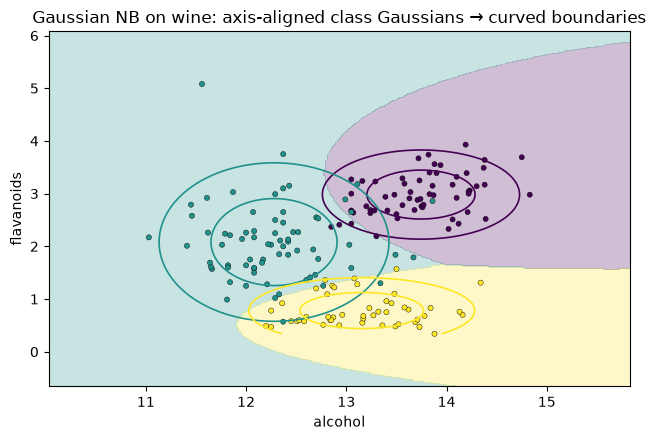

GaussianNB 5-fold accuracy on all 13 wine features (no scaling needed): 0.972


In [9]:
wine = load_wine(as_frame=True)
features_2d = ["alcohol", "flavanoids"]
X2 = wine.data[features_2d].to_numpy()
y2 = wine.target.to_numpy()
gnb_2d = GaussianNB().fit(X2, y2)
print(pd.DataFrame(np.hstack([gnb_2d.theta_, gnb_2d.var_]), columns=["mean alcohol", "mean flavanoids", "var alcohol", "var flavanoids"],
                   index=[f"class {c}" for c in gnb_2d.classes_]).round(3))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
display = DecisionBoundaryDisplay.from_estimator(gnb_2d, X2, response_method="predict", alpha=0.25, ax=ax,
                                                 grid_resolution=300, multiclass_colors="viridis")
colors = ListedColormap(display.multiclass_colors_)
ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap=colors, s=14, edgecolor="k", linewidth=0.3)
gx, gy = np.meshgrid(np.linspace(X2[:, 0].min(), X2[:, 0].max(), 200), np.linspace(X2[:, 1].min(), X2[:, 1].max(), 200))
for c in range(3):
    density = np.exp(-0.5 * (((gx - gnb_2d.theta_[c, 0]) ** 2) / gnb_2d.var_[c, 0] + ((gy - gnb_2d.theta_[c, 1]) ** 2) / gnb_2d.var_[c, 1]))
    ax.contour(gx, gy, density, levels=[0.1, 0.5], colors=[display.multiclass_colors_[c]], linewidths=1.2)
ax.set(xlabel="alcohol", ylabel="flavanoids", title="Gaussian NB on wine: axis-aligned class Gaussians → curved boundaries")
plt.tight_layout()
plt.show()

wine_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print(f"GaussianNB 5-fold accuracy on all 13 wine features (no scaling needed): "
      f"{cross_val_score(GaussianNB(), wine.data, wine.target, cv=wine_folds).mean():.3f}")

**The `var_smoothing` hyperparameter matters more than its tiny default suggests.** On handwritten digits many border pixels are almost always 0 inside a class, so their variance is nearly 0 and a single stray ink pixel makes that class look impossible. A validation curve on real data shows the effect.

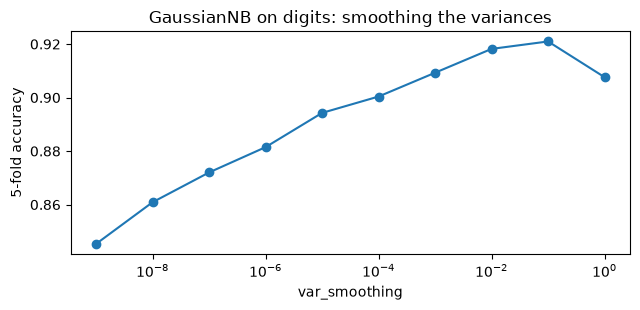

default var_smoothing=1e-9: 0.845 | best 1e-01: 0.921


In [10]:
digits = load_digits()
digit_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
smoothing_grid = np.logspace(-9, 0, 10)
_, vs_scores = validation_curve(GaussianNB(), digits.data, digits.target, param_name="var_smoothing",
                                param_range=smoothing_grid, cv=digit_folds)
vs_mean = vs_scores.mean(axis=1)
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogx(smoothing_grid, vs_mean, "o-")
ax.set(xlabel="var_smoothing", ylabel="5-fold accuracy", title="GaussianNB on digits: smoothing the variances")
plt.tight_layout()
plt.show()
print(f"default var_smoothing=1e-9: {vs_mean[0]:.3f} | best {smoothing_grid[vs_mean.argmax()]:.0e}: {vs_mean.max():.3f}")

> 💡 **Interview angle:** "What does Gaussian Naive Bayes learn, and what shape is its boundary?" — per-class feature means and variances (and priors). Separate variances per class → quadratic boundary; shared variances → linear (it becomes a special case of LDA with a diagonal covariance). It needs no feature scaling, but near-zero variances need smoothing.

## 5. Multinomial Naive Bayes for Counts 🟢

For **word counts** (bag-of-words), `MultinomialNB` treats a document as words drawn one by one from a class-specific distribution $\theta_c$ over the vocabulary:

$$\hat\theta_{cj} = \frac{N_{cj} + \alpha}{N_c + \alpha d}, \qquad \ell_c = \log P(c) + \sum_j x_j \log \hat\theta_{cj}$$

where $N_{cj}$ is how often word $j$ appears in class $c$ documents, $N_c$ the total word count of class $c$, and $d$ the vocabulary size. A word that appears 3 times counts 3 times; **absent words are ignored**. It also works well with TF-IDF values (fractional counts).

You already built Multinomial NB from scratch and matched scikit-learn in [Classical NLP](../05_NLP/01_Classical_NLP.ipynb) (Build It From Scratch, part 2), so here we focus on *using* and *reading* it. On the SMS data, the words with the largest $\log\hat\theta_{\text{spam},j} - \log\hat\theta_{\text{ham},j}$ are the model's strongest spam signals.

In [11]:
sms_counter = CountVectorizer().fit(sms_train["text"])
Xs_tr, Xs_te = sms_counter.transform(sms_train["text"]), sms_counter.transform(sms_test["text"])
ys_tr, ys_te = sms_train["spam"].to_numpy(), sms_test["spam"].to_numpy()

mnb_sms = MultinomialNB(alpha=1.0).fit(Xs_tr, ys_tr)
vocab = sms_counter.get_feature_names_out()
log_ratio = mnb_sms.feature_log_prob_[1] - mnb_sms.feature_log_prob_[0]
top = np.argsort(log_ratio)
print("strongest spam words:", ", ".join(f"{vocab[i]} ({log_ratio[i]:+.1f})" for i in top[::-1][:10]))
print("strongest ham words :", ", ".join(f"{vocab[i]} ({log_ratio[i]:+.1f})" for i in top[:10]))

sms_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_f1 = cross_val_score(make_pipeline(CountVectorizer(), MultinomialNB()), sms_train["text"], ys_tr, cv=sms_folds, scoring="f1")
print(f"\nCountVectorizer + MultinomialNB: 5-fold spam F1 {cv_f1.mean():.3f} ± {cv_f1.std():.3f} on the training split")

strongest spam words: claim (+5.3), prize (+5.2), 150p (+4.8), nokia (+4.8), tone (+4.6), co (+4.6), www (+4.6), 18 (+4.6), guaranteed (+4.5), 500 (+4.5)
strongest ham words : gt (-4.4), lt (-4.4), he (-4.2), lor (-3.9), da (-3.8), she (-3.7), later (-3.4), really (-3.2), but (-3.2), doing (-3.2)

CountVectorizer + MultinomialNB: 5-fold spam F1 0.936 ± 0.023 on the training split


> 💡 **Interview angle:** "Multinomial vs Bernoulli NB?" — Multinomial models *how many times* each word occurs and ignores absent words; Bernoulli models *whether* each vocabulary word occurs and explicitly penalizes absent ones. Multinomial usually wins on longer documents; Bernoulli can do well on short texts (Section 7 measures both).

## 6. Smoothing and the Zero-Frequency Problem 🟡

Without smoothing, $\hat\theta_{cj} = N_{cj}/N_c$. If the word "lecture" never appeared in any training spam, then $P(\text{"lecture"} \mid \text{spam}) = 0$, and **one** such word makes the whole product 0 ($\log = -\infty$): no amount of "WINNER", "prize" and "claim" can save it. Worse, if a message contains a spam-only word *and* a ham-only word, both classes score $-\infty$ and the posterior is undefined.

**Additive smoothing** pretends every word was seen $\alpha$ extra times in every class:

$$\hat\theta_{cj} = \frac{N_{cj} + \alpha}{N_c + \alpha d}$$

- $\alpha = 1$: **Laplace** smoothing. $0 < \alpha < 1$: **Lidstone** smoothing. Bernoulli uses $\frac{N_{cj} + \alpha}{n_c + 2\alpha}$ (two outcomes: present/absent).
- Bayesian view: $\alpha$ is a symmetric Dirichlet prior over the word distribution; the estimate is the posterior mean.
- Bigger $\alpha$ pulls every class toward uniform word probabilities (more bias, less variance). Tune it on a log scale.

scikit-learn silently raises `alpha < 1e-10` to `1e-10` unless `force_alpha=True`. We force a true zero to see the problem.

In [12]:
with np.errstate(divide="ignore", invalid="ignore"):                          # log(0) = -inf is the point of this demo
    unsmoothed = MultinomialNB(alpha=0.0, force_alpha=True).fit(Xs_tr, ys_tr)
    log_post = unsmoothed.predict_log_proba(Xs_te)
    unsmoothed_pred = unsmoothed.predict(Xs_te)
smoothed_pred = mnb_sms.predict(Xs_te)
undefined = np.isnan(log_post).any(axis=1)
certain = ~undefined & np.isclose(np.exp(log_post).max(axis=1), 1.0)

print(f"alpha=0: {np.isinf(unsmoothed.feature_log_prob_).mean():.1%} of word probabilities are exactly 0 (log = -inf)")
print(f"alpha=0: {undefined.mean():.1%} of test messages have an undefined posterior (−inf for both classes), "
      f"{certain.mean():.1%} get a 100%-certain posterior")
print(f"spam F1 — alpha=0: {f1_score(ys_te, unsmoothed_pred):.3f} | alpha=1: {f1_score(ys_te, smoothed_pred):.3f}")

alpha=0: 44.0% of word probabilities are exactly 0 (log = -inf)
alpha=0: 7.8% of test messages have an undefined posterior (−inf for both classes), 84.1% get a 100%-certain posterior
spam F1 — alpha=0: 0.716 | alpha=1: 0.921


Now tune $\alpha$ properly: a validation curve with cross-validation on the **training** split, vectorizer inside the pipeline.

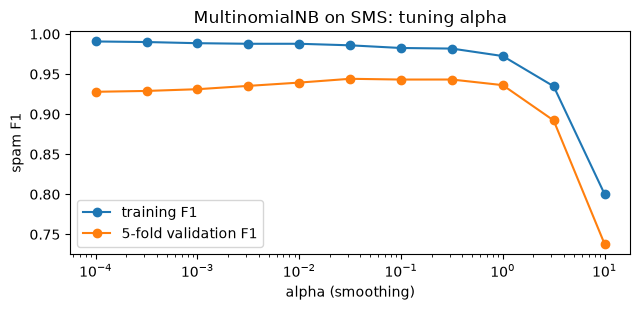

best alpha 0.0316 (validation F1 0.944) | alpha=10 gives 0.738 (over-smoothed: spam words get diluted)


In [13]:
alpha_grid = np.logspace(-4, 1, 11)
alpha_train, alpha_val = validation_curve(make_pipeline(CountVectorizer(), MultinomialNB()), sms_train["text"], ys_tr,
                                          param_name="multinomialnb__alpha", param_range=alpha_grid, cv=sms_folds, scoring="f1")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogx(alpha_grid, alpha_train.mean(axis=1), "o-", label="training F1")
ax.semilogx(alpha_grid, alpha_val.mean(axis=1), "o-", label="5-fold validation F1")
ax.set(xlabel="alpha (smoothing)", ylabel="spam F1", title="MultinomialNB on SMS: tuning alpha")
ax.legend()
plt.tight_layout()
plt.show()
best_alpha = alpha_grid[alpha_val.mean(axis=1).argmax()]
print(f"best alpha {best_alpha:.3g} (validation F1 {alpha_val.mean(axis=1).max():.3f}) | "
      f"alpha=10 gives {alpha_val.mean(axis=1)[-1]:.3f} (over-smoothed: spam words get diluted)")

### ✍️ Your Turn

A word never appeared in class $c$ ($N_{cj} = 0$). Class $c$'s documents contain $N_c = 1000$ words in total, and the vocabulary has $d = 5000$ words. What is the Laplace-smoothed estimate $\hat\theta_{cj}$ with $\alpha = 1$?

In [14]:
N_cj, N_c, vocab_size, alpha = 0, 1000, 5000, 1.0
theta_smoothed = None  # TODO: your code here
check("theta_smoothed", theta_smoothed, 1 / 6000, hint="(N_cj + alpha) / (N_c + alpha * vocab_size)")

⏳ theta_smoothed: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
N_cj, N_c, vocab_size, alpha = 0, 1000, 5000, 1.0
theta_smoothed = (N_cj + alpha) / (N_c + alpha * vocab_size)
check("theta_smoothed", theta_smoothed, 1 / 6000)
```

Note how much mass smoothing moves: the class saw only 1,000 real words but gets 5,000 pseudo-counts. With a large vocabulary and little data, $\alpha = 1$ can over-smooth, which is why smaller α often wins on text.
</details>

> 💡 **Interview angle:** "What is Laplace smoothing and why do we need it?" — add α pseudo-counts to every feature/class so unseen words don't get probability 0, which would zero out the whole product (−∞ in log space). α = 1 is Laplace, 0 < α < 1 Lidstone; it's a Dirichlet prior; tune α by cross-validation.

## 7. Bernoulli Naive Bayes for Binary Features 🟡

`BernoulliNB` models each vocabulary word as a coin flip: present ($x_j = 1$) or absent ($x_j = 0$):

$$P(x \mid c) = \prod_j p_{cj}^{x_j}(1 - p_{cj})^{1 - x_j}, \qquad \hat p_{cj} = \frac{n_{cj} + \alpha}{n_c + 2\alpha}$$

with $n_{cj}$ = number of class-$c$ documents containing word $j$. Unlike Multinomial NB, an **absent** word is evidence too: if "prize" appears in 30% of spam, *not* seeing it multiplies the spam score by 0.7. The `binarize` parameter (default 0.0) turns any input value above the threshold into 1.

Classic finding (McCallum & Nigam, 1998): Bernoulli is competitive on short texts with small vocabularies, and Multinomial pulls ahead on longer documents. Let's measure on short SMS messages and long newsgroup posts, with fixed settings and each dataset's official held-out part.

In [15]:
length_rows = []
datasets = {
    "SMS (short)": (sms_train["text"], ys_tr, sms_test["text"], ys_te),
    "20 Newsgroups (long)": (news_train.data, news_train.target, news_test.data, news_test.target),
}
for name, (text_tr, y_tr_, text_te, y_te_) in datasets.items():
    counter = CountVectorizer(min_df=2).fit(text_tr)
    C_tr, C_te = counter.transform(text_tr), counter.transform(text_te)
    row = {"dataset": name, "median tokens / doc": float(np.median(np.asarray(C_tr.sum(axis=1)).ravel())),
           "vocabulary": C_tr.shape[1]}
    for model_name, model in [("MultinomialNB", MultinomialNB(alpha=0.1)), ("BernoulliNB", BernoulliNB(alpha=0.1))]:
        pred = model.fit(C_tr, y_tr_).predict(C_te)
        row[f"{model_name} macro-F1"] = f1_score(y_te_, pred, average="macro")
    length_rows.append(row)
length_table = pd.DataFrame(length_rows).set_index("dataset")
print(length_table.round(3))
for name, r in length_table.iterrows():
    gap = r["MultinomialNB macro-F1"] - r["BernoulliNB macro-F1"]
    print(f"{name}: Multinomial minus Bernoulli = {gap:+.3f}")

                      median tokens / doc  vocabulary  MultinomialNB macro-F1  \
dataset                                                                         
SMS (short)                          10.0        3310                   0.952   
20 Newsgroups (long)                 78.0       39423                   0.620   

                      BernoulliNB macro-F1  
dataset                                     
SMS (short)                          0.968  
20 Newsgroups (long)                 0.524  
SMS (short): Multinomial minus Bernoulli = -0.016
20 Newsgroups (long): Multinomial minus Bernoulli = +0.095


> 💡 **Interview angle:** "When would you use Bernoulli NB?" — binary features (word presence, one-hot flags, yes/no attributes) and short texts where "this word is missing" is informative. On long documents, absent-word penalties from a huge vocabulary swamp the signal and counts matter, so Multinomial usually wins.

## 8. Complement Naive Bayes for Imbalanced Text 🟡

Multinomial NB estimates each class's word distribution from **that class's documents only**. A rare class has few words, so its estimates are noisy and dominated by smoothing, and the big classes win almost every document.

**Complement NB** (Rennie et al., 2003) estimates, for each class, the word distribution of **all the other classes** (the complement), which always has plenty of data, then predicts the class whose complement fits the document **worst**:

$$\hat\theta_{\tilde c j} = \frac{\alpha + \sum_{i: y_i \ne c} x_{ij}}{\alpha d + \sum_{i: y_i \ne c} \sum_k x_{ik}}, \qquad w_{cj} = -\log \hat\theta_{\tilde c j}, \qquad \hat y = \arg\max_c \sum_j x_j\, w_{cj}$$

(scikit-learn's default `norm=False`; `norm=True` also normalizes the weights as in the paper.) We make 20 Newsgroups **imbalanced on purpose** by keeping all training posts for 5 topics and a random 10% for the other 15, then evaluate on the full (balanced) official test set with fixed settings.

In [16]:
keep_fraction = np.where(np.arange(20) < 5, 1.0, 0.10)
keep = rng.random(len(news_train.target)) < keep_fraction[news_train.target]
imb_text = [doc for doc, k in zip(news_train.data, keep) if k]
imb_y = news_train.target[keep]
print("training posts per topic:", np.bincount(imb_y).tolist())

tfidf_imb = TfidfVectorizer(sublinear_tf=True, min_df=2).fit(imb_text)
T_tr, T_te = tfidf_imb.transform(imb_text), tfidf_imb.transform(news_test.data)
imb_models = {
    "MultinomialNB": MultinomialNB(alpha=0.1),
    "ComplementNB": ComplementNB(alpha=0.1),
    "LogisticRegression": LogisticRegression(C=10, max_iter=2000),
    "LinearSVC": LinearSVC(),
}
imb_rows = {}
minority = np.arange(5, 20)
for name, model in imb_models.items():
    start = time.perf_counter(); model.fit(T_tr, imb_y); fit_s = time.perf_counter() - start
    pred = model.predict(T_te)
    per_class_recall = recall_score(news_test.target, pred, average=None)
    imb_rows[name] = {"accuracy": accuracy_score(news_test.target, pred), "macro-F1": f1_score(news_test.target, pred, average="macro"),
                      "recall on 15 rare topics": per_class_recall[minority].mean(),
                      "recall on 5 big topics": per_class_recall[:5].mean(), "fit s": fit_s}
imb_table = pd.DataFrame(imb_rows).T.sort_values("macro-F1", ascending=False)
print(imb_table.round(3))
print(f"\nComplementNB vs MultinomialNB macro-F1: {imb_table.loc['ComplementNB', 'macro-F1']:.3f} vs "
      f"{imb_table.loc['MultinomialNB', 'macro-F1']:.3f}; best overall: {imb_table.index[0]}")

training posts per topic: [480, 584, 591, 590, 578, 82, 69, 57, 62, 56, 48, 54, 66, 64, 49, 56, 45, 49, 53, 30]


                    accuracy  macro-F1  recall on 15 rare topics  \
ComplementNB           0.476     0.466                     0.367   
LinearSVC              0.457     0.456                     0.347   
LogisticRegression     0.355     0.340                     0.212   
MultinomialNB          0.211     0.124                     0.027   

                    recall on 5 big topics  fit s  
ComplementNB                         0.767  0.004  
LinearSVC                            0.755  0.151  
LogisticRegression                   0.766  2.555  
MultinomialNB                        0.765  0.005  

ComplementNB vs MultinomialNB macro-F1: 0.466 vs 0.124; best overall: ComplementNB


Multinomial NB sends most documents to the big topics (high recall there, very low on rare topics). Complement NB fixes most of that at the same near-zero training cost, and here it is competitive with the linear models.

> 💡 **Interview angle:** "Your Naive Bayes text classifier ignores small classes. What do you try?" — `ComplementNB` (estimates from the complement classes, designed for imbalance), `class_prior`/`fit_prior=False`, threshold tuning, macro-F1 or per-class recall as the metric, and compare with class-weighted logistic regression or a linear SVM.

## 9. Categorical Naive Bayes 🟡

When features are **categories** (odor = almond / foul / none …), `CategoricalNB` estimates a smoothed frequency table per feature and class:

$$P(x_j = t \mid c) = \frac{N_{cjt} + \alpha}{N_c + \alpha\, n_j}$$

where $n_j$ is the number of categories of feature $j$. Inputs must be integer codes `0..n_j-1`, so put an `OrdinalEncoder` first. Two practical details:

- Give the encoder the **full list of categories** from the data schema (not only those seen in a training fold), and set `min_categories`, so a rare category that lands only in a validation fold doesn't crash.
- Missing values become their own "missing" category.

We use the real **mushroom** dataset and compare with the common alternatives on the same folds.

In [17]:
mushroom = fetch_openml(data_id=24, as_frame=True, data_home=DATA_HOME, parser="pandas")
X_mush = mushroom.data.apply(lambda col: col.astype("category").cat.add_categories("missing").fillna("missing"))
y_mush = (mushroom.target == "p").astype(int).to_numpy()
schema_categories = [X_mush[col].cat.categories.tolist() for col in X_mush.columns]
print(f"mushroom: {X_mush.shape}, poisonous {y_mush.mean():.1%}, "
      f"categories per feature {min(map(len, schema_categories))}–{max(map(len, schema_categories))}")

mush_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
mush_models = {
    "CategoricalNB (ordinal codes)": make_pipeline(OrdinalEncoder(categories=schema_categories),
                                                   CategoricalNB(min_categories=np.array([len(c) for c in schema_categories]))),
    "BernoulliNB (one-hot)": make_pipeline(OneHotEncoder(categories=schema_categories), BernoulliNB()),
    "GaussianNB (ordinal codes, wrong model)": make_pipeline(OrdinalEncoder(categories=schema_categories), GaussianNB()),
    "LogisticRegression (one-hot)": make_pipeline(OneHotEncoder(categories=schema_categories), LogisticRegression(max_iter=2000)),
}
mush_scores = pd.Series({name: cross_val_score(model, X_mush, y_mush, cv=mush_folds).mean() for name, model in mush_models.items()},
                        name="5-fold accuracy").sort_values(ascending=False)
print(mush_scores.round(4))

cat_nb = mush_models["CategoricalNB (ordinal codes)"].fit(X_mush, y_mush)
odor_index = list(X_mush.columns).index("odor")
odor_table = pd.DataFrame(np.exp(cat_nb[-1].feature_log_prob_[odor_index]).T, index=schema_categories[odor_index],
                          columns=["P(odor | edible)", "P(odor | poisonous)"])
print("\n", odor_table.round(3))

mushroom: (8124, 22), poisonous 48.2%, categories per feature 2–13


LogisticRegression (one-hot)               1.0000
CategoricalNB (ordinal codes)              0.9527
BernoulliNB (one-hot)                      0.9409
GaussianNB (ordinal codes, wrong model)    0.9243
Name: 5-fold accuracy, dtype: float64

          P(odor | edible)  P(odor | poisonous)
a                   0.095                0.000
c                   0.000                0.049
f                   0.000                0.550
l                   0.095                0.000
m                   0.000                0.009
n                   0.808                0.031
p                   0.000                0.065
s                   0.000                0.147
y                   0.000                0.147
missing             0.000                0.000


CategoricalNB clearly beats GaussianNB on the same codes (category codes aren't bell curves), and one-hot + Bernoulli is a close alternative. Logistic regression does better still: several features interact, and a discriminative model captures that. The odor table shows why NB is interpretable: some odors are almost perfectly tied to one class.

> 💡 **Interview angle:** "How do you use Naive Bayes with categorical features?" — `CategoricalNB` on ordinal codes (a smoothed frequency table per feature and class, with `min_categories` for unseen levels), or one-hot + `BernoulliNB`. Never `GaussianNB` on codes: it assumes an order and a bell curve that don't exist.

## 10. Why "Naive" Still Works: Good Rankings, Poor Probabilities 🔴

Real features are rarely independent. On the breast-cancer data, radius, perimeter and area measure almost the same thing. So why does Naive Bayes still classify well?

- **Classification only needs the argmax.** Domingos & Pazzani (1997) showed that Naive Bayes can be optimal under 0-1 loss even when independence is badly violated, as long as the *highest-scoring* class stays the same. Double-counted evidence often pushes all scores in the same direction.
- **But the probabilities pay the price.** Counting correlated evidence twice pushes posteriors towards 0 and 1: the model is **overconfident**. Ranking metrics (accuracy, ROC-AUC) barely move while probability metrics (log loss, Brier score) get much worse.

**Experiment:** we give GaussianNB the real breast-cancer features, then 2, 4 and 8 identical copies of them. Copies are perfectly correlated, so the independence assumption is maximally violated, and each piece of evidence gets counted 2–8 times. (A controlled manipulation of real data.)

In [18]:
cancer = load_breast_cancer()
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(cancer.data, cancer.target, test_size=0.3, stratify=cancer.target, random_state=SEED)
corr = np.corrcoef(Xc_tr, rowvar=False)
print(f"mean |correlation| between different features: {np.abs(corr[np.triu_indices_from(corr, k=1)]).mean():.2f} "
      f"| share of pairs with |r| > 0.8: {(np.abs(corr[np.triu_indices_from(corr, k=1)]) > 0.8).mean():.1%}")

copy_rows, copy_probas = [], {}
for copies in [1, 2, 4, 8]:
    p = GaussianNB().fit(np.tile(Xc_tr, copies), yc_tr).predict_proba(np.tile(Xc_te, copies))[:, 1]
    copy_probas[copies] = p
    copy_rows.append({"feature copies": copies, "accuracy": accuracy_score(yc_te, p > 0.5), "ROC-AUC": roc_auc_score(yc_te, p),
                      "log loss": log_loss(yc_te, p), "Brier": brier_score_loss(yc_te, p),
                      "share of p < 0.001 or > 0.999": ((p < 0.001) | (p > 0.999)).mean()})
lr_p = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)).fit(Xc_tr, yc_tr).predict_proba(Xc_te)[:, 1]
copy_rows.append({"feature copies": "logistic regression (1)", "accuracy": accuracy_score(yc_te, lr_p > 0.5),
                  "ROC-AUC": roc_auc_score(yc_te, lr_p), "log loss": log_loss(yc_te, lr_p), "Brier": brier_score_loss(yc_te, lr_p),
                  "share of p < 0.001 or > 0.999": ((lr_p < 0.001) | (lr_p > 0.999)).mean()})
copy_table = pd.DataFrame(copy_rows).set_index("feature copies")
print(copy_table.round(4))
t = copy_table.iloc[:4]
print(f"\n1 → 8 copies: accuracy {t['accuracy'].iloc[0]:.3f} → {t['accuracy'].iloc[-1]:.3f}, AUC {t['ROC-AUC'].iloc[0]:.3f} → "
      f"{t['ROC-AUC'].iloc[-1]:.3f}, but log loss {t['log loss'].iloc[0]:.2f} → {t['log loss'].iloc[-1]:.2f} "
      f"({t['log loss'].iloc[-1] / t['log loss'].iloc[0]:.1f}× worse).")

mean |correlation| between different features: 0.40 | share of pairs with |r| > 0.8: 10.8%
                         accuracy  ROC-AUC  log loss   Brier  \
feature copies                                                 
1                          0.9474   0.9901    0.3382  0.0493   
2                          0.9415   0.9901    0.6405  0.0527   
4                          0.9415   0.9702    1.0781  0.0560   
8                          0.9357   0.9568    1.4688  0.0591   
logistic regression (1)    0.9883   0.9981    0.0655  0.0170   

                         share of p < 0.001 or > 0.999  
feature copies                                          
1                                               0.9181  
2                                               0.9532  
4                                               0.9649  
8                                               0.9766  
logistic regression (1)                         0.4444  

1 → 8 copies: accuracy 0.947 → 0.936, AUC 0.990 → 0.957, but

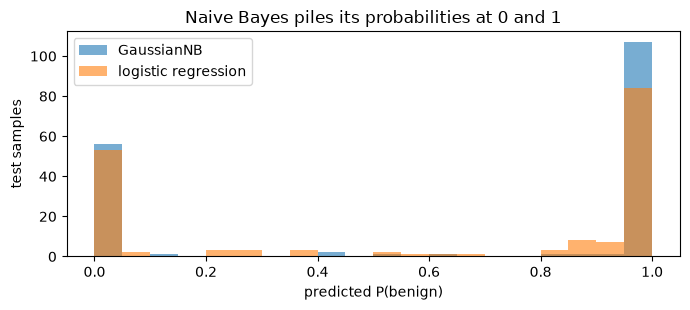

In [19]:
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, 1, 21)
ax.hist(copy_probas[1], bins=bins, alpha=0.6, label="GaussianNB")
ax.hist(lr_p, bins=bins, alpha=0.6, label="logistic regression")
ax.set(xlabel="predicted P(benign)", ylabel="test samples", title="Naive Bayes piles its probabilities at 0 and 1")
ax.legend()
plt.tight_layout()
plt.show()

> 💡 **Interview angle:** "The independence assumption is clearly false — why does Naive Bayes work?" — classification needs only the correct argmax, and violations often shift all class scores similarly (Domingos & Pazzani); it also has low variance, so it does well with little data. The cost is overconfident probabilities: accuracy/AUC stay fine while log loss and Brier score suffer, so calibrate before using the probabilities.

## 11. Calibration: Reliability Curves and CalibratedClassifierCV 🔴

A classifier is **calibrated** when its "80%" predictions are right about 80% of the time. (The general theory is in [ML Fundamentals From Scratch](01_ML_Fundamentals_From_Scratch.ipynb), Section 11.) To check and fix Naive Bayes:

- **Reliability curve**: bin predictions, plot mean predicted probability vs the observed fraction of positives. The diagonal is perfect.
- **Brier score** $= \frac1n\sum_i (p_i - y_i)^2$ and **log loss**: lower is better; both punish overconfidence.
- **`CalibratedClassifierCV`** learns a mapping from the model's scores to calibrated probabilities on data the model did **not** train on: `method="sigmoid"` (Platt scaling, 2 parameters, good for small data) or `"isotonic"` (a free-form monotonic step function, needs more data). With `cv=5` it trains 5 model+calibrator pairs and averages them; if you already have a fitted model and a separate calibration set, wrap it as `FrozenEstimator(model)`.

Calibration is **monotonic**, so it changes probabilities and (slightly) thresholds, but ROC-AUC stays about the same.

                                        ROC-AUC  log loss   Brier
GaussianNB (raw)                         0.9901    0.3382  0.0493
GaussianNB + sigmoid (cv=5)              0.9899    0.2028  0.0490
GaussianNB + isotonic (cv=5)             0.9899    0.1281  0.0415
GaussianNB + sigmoid (FrozenEstimator)   0.9896    0.2179  0.0531

Best log loss: GaussianNB + isotonic (cv=5) (0.128 vs raw 0.338); AUC range across rows 0.990–0.990


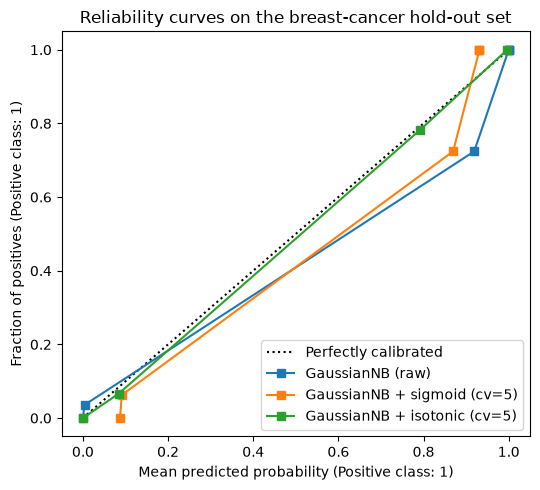

In [20]:
calibration_models = {
    "GaussianNB (raw)": GaussianNB(),
    "GaussianNB + sigmoid (cv=5)": CalibratedClassifierCV(GaussianNB(), method="sigmoid", cv=5),
    "GaussianNB + isotonic (cv=5)": CalibratedClassifierCV(GaussianNB(), method="isotonic", cv=5),
}
cal_rows, cal_probas = {}, {}
for name, model in calibration_models.items():
    p = model.fit(Xc_tr, yc_tr).predict_proba(Xc_te)[:, 1]
    cal_probas[name] = p
    cal_rows[name] = {"ROC-AUC": roc_auc_score(yc_te, p), "log loss": log_loss(yc_te, p), "Brier": brier_score_loss(yc_te, p)}

# The "prefit" pattern: train on one part, calibrate on a separate part, never on the training rows
Xfit, Xcal, yfit, ycal = train_test_split(Xc_tr, yc_tr, test_size=0.4, stratify=yc_tr, random_state=SEED)
frozen = CalibratedClassifierCV(FrozenEstimator(GaussianNB().fit(Xfit, yfit)), method="sigmoid").fit(Xcal, ycal)
p = frozen.predict_proba(Xc_te)[:, 1]
cal_probas["GaussianNB + sigmoid (FrozenEstimator)"] = p
cal_rows["GaussianNB + sigmoid (FrozenEstimator)"] = {"ROC-AUC": roc_auc_score(yc_te, p), "log loss": log_loss(yc_te, p),
                                                      "Brier": brier_score_loss(yc_te, p)}
cal_table = pd.DataFrame(cal_rows).T
print(cal_table.round(4))
best_cal = cal_table["log loss"].idxmin()
print(f"\nBest log loss: {best_cal} ({cal_table.loc[best_cal, 'log loss']:.3f} vs raw {cal_table.loc['GaussianNB (raw)', 'log loss']:.3f}); "
      f"AUC range across rows {cal_table['ROC-AUC'].min():.3f}–{cal_table['ROC-AUC'].max():.3f}")

fig, ax = plt.subplots(figsize=(5.5, 5))
for name in ["GaussianNB (raw)", "GaussianNB + sigmoid (cv=5)", "GaussianNB + isotonic (cv=5)"]:
    CalibrationDisplay.from_predictions(yc_te, cal_probas[name], n_bins=6, strategy="quantile", name=name, ax=ax)
ax.set(title="Reliability curves on the breast-cancer hold-out set")
plt.tight_layout()
plt.show()

### ✍️ Your Turn

Compute the **Brier score** for true labels `[1, 0, 1]` and predicted probabilities `[0.9, 0.2, 0.6]`.

In [21]:
y_small = np.array([1, 0, 1])
p_small = np.array([0.9, 0.2, 0.6])
brier = None  # TODO: your code here
check("brier", brier, 0.07, hint="Mean of the squared differences (p - y) ** 2.")

⏳ brier: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
y_small = np.array([1, 0, 1])
p_small = np.array([0.9, 0.2, 0.6])
brier = np.mean((p_small - y_small) ** 2)
check("brier", brier, 0.07)
```

(0.01 + 0.04 + 0.16) / 3 = 0.07. `sklearn.metrics.brier_score_loss(y_small, p_small)` gives the same.
</details>

> 💡 **Interview angle:** "Can you use Naive Bayes probabilities as risk scores?" — not raw: they're overconfident. Check a reliability curve and Brier/log loss on held-out data, then calibrate with `CalibratedClassifierCV` (sigmoid for small data, isotonic for more), fitting the calibrator on data the model didn't train on (cross-validation or `FrozenEstimator` + a calibration split).

## 12. Speed at Scale and Streaming With partial_fit 🟡

Naive Bayes training is a single pass of sums, so it scales linearly and needs no iterations. We measure fit and predict time on 20 Newsgroups TF-IDF features (11,314 posts × ~40k words) and on the same posts stacked 4× and 16× (a controlled way to grow the number of rows with an identical vocabulary), against logistic regression (L-BFGS) and a linear SGD classifier.

In [22]:
tfidf_news = TfidfVectorizer(sublinear_tf=True, min_df=2).fit(news_train.data)
N_tr, N_te = tfidf_news.transform(news_train.data), tfidf_news.transform(news_test.data)
speed_rows = []
for reps in [1, 4, 16]:
    X_big, y_big = sparse.vstack([N_tr] * reps).tocsr(), np.tile(news_train.target, reps)
    speed_models = {"MultinomialNB": MultinomialNB(alpha=0.01), "ComplementNB": ComplementNB(alpha=0.3),
                    "SGDClassifier (log loss)": SGDClassifier(loss="log_loss", alpha=1e-5, max_iter=20, tol=None, random_state=SEED)}
    if reps <= 4:                                         # L-BFGS gets slow: keep the notebook's runtime reasonable
        speed_models["LogisticRegression (lbfgs)"] = LogisticRegression(C=10, max_iter=1000)
    for name, model in speed_models.items():
        start = time.perf_counter(); model.fit(X_big, y_big); fit_s = time.perf_counter() - start
        start = time.perf_counter(); pred = model.predict(N_te); predict_s = time.perf_counter() - start
        speed_rows.append({"rows": X_big.shape[0], "model": name, "fit s": fit_s, "predict s (7,532 docs)": predict_s,
                           "test accuracy": accuracy_score(news_test.target, pred)})
    del X_big, y_big
    gc.collect()
speed_table = pd.DataFrame(speed_rows)
print(speed_table.pivot(index="model", columns="rows", values="fit s").round(3))
print("\n", speed_table[speed_table["rows"] == N_tr.shape[0]].set_index("model")[["predict s (7,532 docs)", "test accuracy"]].round(3))
fit_1 = speed_table.set_index(["model", "rows"])["fit s"]
print(f"\nOn {N_tr.shape[0]:,} rows MultinomialNB trains {fit_1[('LogisticRegression (lbfgs)', N_tr.shape[0])] / fit_1[('MultinomialNB', N_tr.shape[0])]:.0f}× "
      f"faster than L-BFGS logistic regression; going 1× → 16× rows multiplies its fit time by "
      f"{fit_1[('MultinomialNB', 16 * N_tr.shape[0])] / fit_1[('MultinomialNB', N_tr.shape[0])]:.1f}.")

rows                        11314   45256   181024
model                                             
ComplementNB                 0.010   0.023   0.081
LogisticRegression (lbfgs)   4.225   7.714     NaN
MultinomialNB                0.010   0.023   0.083
SGDClassifier (log loss)     0.974   4.743  20.146

                             predict s (7,532 docs)  test accuracy
model                                                            
MultinomialNB                                0.005          0.691
ComplementNB                                 0.005          0.714
SGDClassifier (log loss)                     0.005          0.694
LogisticRegression (lbfgs)                   0.004          0.690

On 11,314 rows MultinomialNB trains 405× faster than L-BFGS logistic regression; going 1× → 16× rows multiplies its fit time by 8.0.


**Streaming.** When data arrives in batches (or doesn't fit in memory), `partial_fit` adds each batch's counts to the running totals. Two rules: pass the full list of `classes` on the first call, and use a vectorizer that needs no fitting, such as `HashingVectorizer` (it maps words to columns with a hash function, so new words never require a new vocabulary). `alternate_sign=False` keeps values non-negative, as Multinomial NB requires.

Because counts simply add up, streaming Naive Bayes ends up **identical** to training on all the data at once. Let's prove it.

In [23]:
hasher = HashingVectorizer(n_features=2**18, alternate_sign=False, norm=None)
H_te = hasher.transform(news_test.data)
stream_nb = MultinomialNB(alpha=0.01)
order = rng.permutation(len(news_train.data))
stream_rows = []
for batch_number, start in enumerate(range(0, len(order), 2000), start=1):
    batch = order[start:start + 2000]
    stream_nb.partial_fit(hasher.transform([news_train.data[i] for i in batch]), news_train.target[batch],
                          classes=np.arange(20))
    stream_rows.append({"batches seen": batch_number, "documents seen": min(start + 2000, len(order)),
                        "test accuracy": accuracy_score(news_test.target, stream_nb.predict(H_te))})
print(pd.DataFrame(stream_rows).set_index("batches seen").round(4))

batch_nb = MultinomialNB(alpha=0.01).fit(hasher.transform(news_train.data), news_train.target)
assert np.allclose(stream_nb.feature_count_, batch_nb.feature_count_)
assert np.array_equal(stream_nb.predict(H_te), batch_nb.predict(H_te))
print("✅ streaming partial_fit gives exactly the same model and predictions as one fit on all documents")

              documents seen  test accuracy
batches seen                               
1                       2000         0.5538
2                       4000         0.6040
3                       6000         0.6219
4                       8000         0.6294
5                      10000         0.6413
6                      11314         0.6443


✅ streaming partial_fit gives exactly the same model and predictions as one fit on all documents


> 💡 **Interview angle:** "How would you train a text classifier on a stream of 1 billion messages?" — Naive Bayes (or SGD) with `partial_fit` over mini-batches and a stateless `HashingVectorizer`, so memory is bounded and new vocabulary needs no refit. NB's sufficient statistics are just counts, so the streamed model equals the batch model, counts can be summed across machines (map-reduce), and old data can be decayed for drift.

## 13. A Fair Head-to-Head Comparison 🟡

On **numeric** data, how does Gaussian NB compare with the previous algorithms in this series? Breast cancer, the same 5 folds for every model, and both ranking (accuracy, ROC-AUC) and probability (log loss) metrics, plus fit and prediction time. (The text comparison is the mini project.)

In [24]:
cancer_folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
h2h_models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "KNN (k=15, scaled)": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15)),
    "Random forest (300 trees)": RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
}
h2h_rows = {}
for name, model in h2h_models.items():
    res = cross_validate(model, cancer.data, cancer.target, cv=cancer_folds, scoring=["accuracy", "roc_auc", "neg_log_loss"])
    h2h_rows[name] = {"accuracy": res["test_accuracy"].mean(), "accuracy std": res["test_accuracy"].std(),
                      "ROC-AUC": res["test_roc_auc"].mean(), "log loss": -res["test_neg_log_loss"].mean(),
                      "fit ms": res["fit_time"].mean() * 1000, "score ms": res["score_time"].mean() * 1000}
h2h = pd.DataFrame(h2h_rows).T.sort_values("accuracy", ascending=False)
print(h2h.round(4))
nb_gap = h2h["accuracy"].max() - h2h.loc["Gaussian Naive Bayes", "accuracy"]
print(f"\nBest accuracy: {h2h['accuracy'].idxmax()} | Gaussian NB is {nb_gap:.3f} behind "
      f"({'within' if nb_gap <= h2h['accuracy std'].max() else 'beyond'} the largest fold std {h2h['accuracy std'].max():.3f}) | "
      f"worst log loss: {h2h['log loss'].idxmax()} | fastest fit: {h2h['fit ms'].idxmin()}")

                           accuracy  accuracy std  ROC-AUC  log loss  \
Logistic regression          0.9737        0.0166   0.9953    0.0764   
KNN (k=15, scaled)           0.9596        0.0153   0.9911    0.2228   
Random forest (300 trees)    0.9526        0.0131   0.9895    0.1775   
Gaussian Naive Bayes         0.9385        0.0235   0.9887    0.6598   

                             fit ms  score ms  
Logistic regression          1.4477    1.6645  
KNN (k=15, scaled)           0.5494    7.3281  
Random forest (300 trees)  131.8419   34.4957  
Gaussian Naive Bayes         0.3552    1.3648  

Best accuracy: Logistic regression | Gaussian NB is 0.035 behind (beyond the largest fold std 0.023) | worst log loss: Gaussian Naive Bayes | fastest fit: Gaussian Naive Bayes


Gaussian NB trains fastest and lands a few points of accuracy behind the discriminative models on these strongly correlated measurements, while its log loss is clearly the worst: the overconfidence from Section 10 shows up again. That's the typical profile: a quick, respectable baseline whose probabilities you shouldn't trust raw.

> 💡 **Interview angle:** "Generative vs discriminative: when does Naive Bayes beat logistic regression?" — Ng & Jordan (2001): NB approaches its (higher) asymptotic error much faster, so it can win with very little data; logistic regression wins as data grows because it doesn't rely on the independence assumption. Measure both on the same folds.

## 🔧 Build It From Scratch

Two variants in pure NumPy, asserted to match scikit-learn's learned parameters, `predict_log_proba` and `predict`. (Multinomial NB was built in [Classical NLP](../05_NLP/01_Classical_NLP.ipynb); Complement NB is Exercise 6.)

**Gaussian NB** stores per-class means, variances (plus `var_smoothing × max feature variance`) and priors; the joint log-likelihood is $\log P(c) - \frac12\sum_j[\log(2\pi\sigma^2_{cj}) + (x_j-\mu_{cj})^2/\sigma^2_{cj}]$.

**Bernoulli NB** binarizes, counts documents per word and class, smooths with $\frac{n_{cj}+\alpha}{n_c+2\alpha}$, and scores $\log P(c) + \sum_j [x_j \log p_{cj} + (1-x_j)\log(1-p_{cj})]$, computed as one matrix product.

Both normalize with log-sum-exp.

In [25]:
def normalize_log(jll):
    """Turn joint log-likelihoods (n, C) into log posteriors with a stable log-sum-exp."""
    top = jll.max(axis=1, keepdims=True)
    return jll - (top + np.log(np.exp(jll - top).sum(axis=1, keepdims=True)))


class ScratchGaussianNB:
    def __init__(self, var_smoothing=1e-9):
        self.var_smoothing = var_smoothing

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        self.classes_ = np.unique(y)
        self.epsilon_ = self.var_smoothing * X.var(axis=0).max()
        self.theta_ = np.stack([X[y == c].mean(axis=0) for c in self.classes_])
        self.var_ = np.stack([X[y == c].var(axis=0) for c in self.classes_]) + self.epsilon_
        self.class_prior_ = np.array([(y == c).mean() for c in self.classes_])
        return self

    def joint_log_likelihood(self, X):
        X = np.asarray(X, dtype=float)
        const = -0.5 * np.log(2 * np.pi * self.var_).sum(axis=1)                       # (C,)
        mahal = (((X[:, None, :] - self.theta_[None]) ** 2) / self.var_[None]).sum(axis=2)  # (n, C)
        return np.log(self.class_prior_) + const - 0.5 * mahal

    def predict_log_proba(self, X):
        return normalize_log(self.joint_log_likelihood(X))

    def predict(self, X):
        return self.classes_[self.joint_log_likelihood(X).argmax(axis=1)]


class ScratchBernoulliNB:
    def __init__(self, alpha=1.0, binarize=0.0):
        self.alpha = alpha
        self.binarize = binarize

    def _binary(self, X):
        return (np.asarray(X, dtype=float) > self.binarize).astype(float)

    def fit(self, X, y):
        X = self._binary(X)
        self.classes_ = np.unique(y)
        class_count = np.array([(y == c).sum() for c in self.classes_], dtype=float)
        doc_count = np.stack([X[y == c].sum(axis=0) for c in self.classes_])                # n_cj
        self.class_log_prior_ = np.log(class_count / class_count.sum())
        self.feature_log_prob_ = np.log(doc_count + self.alpha) - np.log(class_count + 2 * self.alpha)[:, None]
        return self

    def joint_log_likelihood(self, X):
        X = self._binary(X)
        log_p = self.feature_log_prob_
        log_not_p = np.log1p(-np.exp(log_p))                                                 # log(1 - p)
        return X @ (log_p - log_not_p).T + self.class_log_prior_ + log_not_p.sum(axis=1)

    def predict_log_proba(self, X):
        return normalize_log(self.joint_log_likelihood(X))

    def predict(self, X):
        return self.classes_[self.joint_log_likelihood(X).argmax(axis=1)]


# Gaussian NB: wine (3 classes, 13 features) and digits (10 classes, var_smoothing matters)
for name, X_all, y_all, smoothing in [("wine", wine.data.to_numpy(), wine.target.to_numpy(), 1e-9),
                                      ("digits", digits.data, digits.target, 1e-2)]:
    X_a, X_b, y_a, y_b = train_test_split(X_all, y_all, test_size=0.3, stratify=y_all, random_state=SEED)
    ours, ref = ScratchGaussianNB(smoothing).fit(X_a, y_a), GaussianNB(var_smoothing=smoothing).fit(X_a, y_a)
    assert np.allclose(ours.theta_, ref.theta_) and np.allclose(ours.var_, ref.var_) and np.allclose(ours.class_prior_, ref.class_prior_)
    assert np.allclose(ours.predict_log_proba(X_b), ref.predict_log_proba(X_b), atol=1e-6)
    assert np.array_equal(ours.predict(X_b), ref.predict(X_b))
    print(f"✅ ScratchGaussianNB matches GaussianNB on {name}: parameters, predict_log_proba and predictions "
          f"(accuracy {accuracy_score(y_b, ours.predict(X_b)):.3f})")

# Bernoulli NB: SMS word counts (binarized inside the model), dense because the vocabulary is small
bern_counter = CountVectorizer(min_df=3).fit(sms_train["text"])
B_tr, B_te = bern_counter.transform(sms_train["text"]).toarray(), bern_counter.transform(sms_test["text"]).toarray()
for alpha in [1.0, 0.1]:
    ours, ref = ScratchBernoulliNB(alpha=alpha).fit(B_tr, ys_tr), BernoulliNB(alpha=alpha).fit(B_tr, ys_tr)
    assert np.allclose(ours.feature_log_prob_, ref.feature_log_prob_) and np.allclose(ours.class_log_prior_, ref.class_log_prior_)
    assert np.allclose(ours.predict_log_proba(B_te), ref.predict_log_proba(B_te), atol=1e-6)
    assert np.array_equal(ours.predict(B_te), ref.predict(B_te))
    print(f"✅ ScratchBernoulliNB (alpha={alpha}) matches BernoulliNB on {B_te.shape[0]:,} SMS test messages × {B_te.shape[1]:,} words "
          f"(spam F1 {f1_score(ys_te, ours.predict(B_te)):.3f})")
del B_tr, B_te

✅ ScratchGaussianNB matches GaussianNB on wine: parameters, predict_log_proba and predictions (accuracy 1.000)
✅ ScratchGaussianNB matches GaussianNB on digits: parameters, predict_log_proba and predictions (accuracy 0.913)
✅ ScratchBernoulliNB (alpha=1.0) matches BernoulliNB on 1,035 SMS test messages × 2,199 words (spam F1 0.932)


✅ ScratchBernoulliNB (alpha=0.1) matches BernoulliNB on 1,035 SMS test messages × 2,199 words (spam F1 0.944)


**Why is Naive Bayes a linear classifier for text?** Look at `joint_log_likelihood` in `ScratchBernoulliNB`: it's `X @ W.T + b`. Multinomial and Bernoulli NB are linear models in log space, just with weights set by counting instead of by minimizing a loss. That's the link to logistic regression, which learns the same form directly.

## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — Duplicate messages leaking across the split

The raw SMS collection contains hundreds of exact duplicates (repeated promotions, "Sorry, I'll call later"). A random split puts copies of the same message in train and test, so the test set partly measures memorization.

In [26]:
raw_train, raw_test = train_test_split(sms_raw, test_size=0.2, stratify=sms_raw["label"], random_state=SEED)
leaked = raw_test["text"].isin(set(raw_train["text"]))
leaked_spam = leaked[raw_test["label"] == "spam"].mean()
print(f"❌ split before de-duplicating: {leaked.mean():.1%} of test messages ({leaked_spam:.1%} of test spam) appear verbatim in training")
clean_leak = sms_test["text"].isin(set(sms_train["text"])).mean()
print(f"✅ de-duplicate first (as in Setup): {clean_leak:.1%} of test messages appear in training")

❌ split before de-duplicating: 12.1% of test messages (22.1% of test spam) appear verbatim in training
✅ de-duplicate first (as in Setup): 0.0% of test messages appear in training


### ❌ Pitfall 2 — Standardized (negative) features in Multinomial NB

In [27]:
try:
    MultinomialNB().fit(StandardScaler().fit_transform(Xc_tr), yc_tr)
except ValueError as err:
    print("❌ ValueError:", err)
print(f"✅ continuous features → GaussianNB (no scaling needed): hold-out accuracy {GaussianNB().fit(Xc_tr, yc_tr).score(Xc_te, yc_te):.3f}")

❌ ValueError: Negative values in data passed to MultinomialNB (input X).
✅ continuous features → GaussianNB (no scaling needed): hold-out accuracy 0.947


### ❌ Pitfall 3 — `partial_fit` without the full list of classes

In [28]:
first_batch = order[:50]
try:
    MultinomialNB().partial_fit(hasher.transform([news_train.data[i] for i in first_batch]), news_train.target[first_batch])
except ValueError as err:
    print("❌ ValueError:", err)
streaming_ok = MultinomialNB().partial_fit(hasher.transform([news_train.data[i] for i in first_batch]),
                                          news_train.target[first_batch], classes=np.arange(20))
print(f"✅ classes=np.arange(20) on the first call: the model knows all {len(streaming_ok.classes_)} topics, "
      f"even though this batch has only {len(np.unique(news_train.target[first_batch]))}")

❌ ValueError: classes must be passed on the first call to partial_fit.
✅ classes=np.arange(20) on the first call: the model knows all 20 topics, even though this batch has only 17


### ❌ Pitfall 4 — Using GaussianNB on count features

Word counts are mostly 0 with a long tail, nothing like a bell curve per class. The Gaussian model still fits without complaint.

In [29]:
small_counter = CountVectorizer(min_df=5).fit(sms_train["text"])
G_tr, G_te = small_counter.transform(sms_train["text"]).toarray(), small_counter.transform(sms_test["text"]).toarray()
gauss_f1 = f1_score(ys_te, GaussianNB().fit(G_tr, ys_tr).predict(G_te))
multi_f1 = f1_score(ys_te, MultinomialNB().fit(G_tr, ys_tr).predict(G_te))
print(f"❌ GaussianNB on word counts: spam F1 {gauss_f1:.3f}")
print(f"✅ MultinomialNB on the same counts: spam F1 {multi_f1:.3f}")
del G_tr, G_te

❌ GaussianNB on word counts: spam F1 0.569
✅ MultinomialNB on the same counts: spam F1 0.935


### ❌ Pitfall 5 — Turning off `var_smoothing` when a feature is constant in a class

Many digit pixels are exactly 0 for every training image of a class, so their variance is 0. With `var_smoothing=0`, the Gaussian log-likelihood divides by zero.

In [30]:
Xd_a, Xd_b, yd_a, yd_b = train_test_split(digits.data, digits.target, test_size=0.3, stratify=digits.target, random_state=SEED)
with np.errstate(divide="ignore", invalid="ignore"):
    no_smoothing = GaussianNB(var_smoothing=0.0).fit(Xd_a, yd_a)
    jll_bad = no_smoothing.predict_joint_log_proba(Xd_b)
    bad_acc = no_smoothing.score(Xd_b, yd_b)
print(f"❌ var_smoothing=0: {(no_smoothing.var_ == 0).mean():.1%} of class variances are 0, "
      f"{(~np.isfinite(jll_bad)).any(axis=1).mean():.1%} of test images get non-finite scores, accuracy {bad_acc:.3f}")
print(f"✅ var_smoothing=1e-2 (tuned in Section 4): accuracy {GaussianNB(var_smoothing=1e-2).fit(Xd_a, yd_a).score(Xd_b, yd_b):.3f}")

❌ var_smoothing=0: 20.9% of class variances are 0, 100.0% of test images get non-finite scores, accuracy 0.100
✅ var_smoothing=1e-2 (tuned in Section 4): accuracy 0.913


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — Fraud alarm posterior
2% of transactions are fraud. The alarm fires for 95% of frauds and for 3% of legitimate transactions. Compute $P(\text{fraud} \mid \text{alarm})$.

In [31]:
p_fraud_given_alarm = None  # TODO
check("p_fraud_given_alarm", p_fraud_given_alarm, 0.3925620, hint="0.95*0.02 / (0.95*0.02 + 0.03*0.98)")

⏳ p_fraud_given_alarm: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_fraud_given_alarm = 0.95 * 0.02 / (0.95 * 0.02 + 0.03 * 0.98)
check("p_fraud_given_alarm", p_fraud_given_alarm, 0.3925620)
```
Even a good alarm is wrong most of the time when fraud is rare: 0.019 true alarms vs 0.0294 false ones.
</details>

### 🟢 Exercise 2 — Log scores to probabilities
Convert the joint log-likelihoods `jll_row` (one sample, three classes) into posterior probabilities without underflow.

In [32]:
jll_row = np.array([-10.0, -12.0, -11.0])
posterior_row = None  # TODO
check("posterior_row", posterior_row, [0.6652410, 0.0900306, 0.2447285], hint="np.exp(jll_row - logsumexp(jll_row))")

⏳ posterior_row: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
jll_row = np.array([-10.0, -12.0, -11.0])
posterior_row = np.exp(jll_row - logsumexp(jll_row))
check("posterior_row", posterior_row, [0.6652410, 0.0900306, 0.2447285])
```
It's a softmax of the log scores; shifting all of them by the same constant changes nothing.
</details>

### 🟢 Exercise 3 — Laplace-smoothed word probabilities
`word_counts[c, j]` is how often word `j` appears in class `c`. Compute the Multinomial NB estimates $\hat\theta_{cj}$ with `alpha = 1` (each row must sum to 1).

In [33]:
word_counts = np.array([[3, 0, 1],
                        [0, 2, 2]])
theta_hat = None  # TODO
check("theta_hat", theta_hat, [[4 / 7, 1 / 7, 2 / 7], [1 / 7, 3 / 7, 3 / 7]],
      hint="(word_counts + 1) / (word_counts + 1).sum(axis=1, keepdims=True)")

⏳ theta_hat: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
word_counts = np.array([[3, 0, 1], [0, 2, 2]])
smoothed = word_counts + 1.0
theta_hat = smoothed / smoothed.sum(axis=1, keepdims=True)
check("theta_hat", theta_hat, [[4 / 7, 1 / 7, 2 / 7], [1 / 7, 3 / 7, 3 / 7]])
```
`MultinomialNB(alpha=1).fit(np.eye(2).repeat(...))` would learn exactly `np.log(theta_hat)` as `feature_log_prob_`.
</details>

### 🟡 Exercise 4 — Gaussian NB posterior by hand
Two classes with equal priors. Class 0 has feature means `[0, 0]` and variances `[1, 1]`; class 1 has means `[2, 1]` and variances `[1, 4]`. For `x = [1, 1]`, compute the joint log-likelihood of each class and return $P(\text{class } 0 \mid x)$.

In [34]:
means = np.array([[0.0, 0.0], [2.0, 1.0]])
variances = np.array([[1.0, 1.0], [1.0, 4.0]])
priors = np.array([0.5, 0.5])
x_point = np.array([1.0, 1.0])
p_class0_gauss = None  # TODO
check("p_class0_gauss", p_class0_gauss, 0.5481372,
      hint="jll = log(prior) - 0.5*sum(log(2π·var)) - 0.5*sum((x - mean)² / var), per class; then normalize.")

⏳ p_class0_gauss: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
means = np.array([[0.0, 0.0], [2.0, 1.0]])
variances = np.array([[1.0, 1.0], [1.0, 4.0]])
priors = np.array([0.5, 0.5])
x_point = np.array([1.0, 1.0])
jll = np.log(priors) - 0.5 * np.log(2 * np.pi * variances).sum(axis=1) - 0.5 * (((x_point - means) ** 2) / variances).sum(axis=1)
p_class0_gauss = np.exp(jll - logsumexp(jll))[0]
check("p_class0_gauss", p_class0_gauss, 0.5481372)
```
Class 1 is equally far in squared distance terms on feature 0, but its larger variance on feature 1 costs it a bigger normalizing term, so class 0 wins slightly.
</details>

### 🟡 Exercise 5 — Bernoulli NB with absent words
Vocabulary: `["prize", "meeting", "hello"]`. $P(\text{word present} \mid \text{spam}) = [0.8, 0.1, 0.5]$, $P(\text{word present} \mid \text{ham}) = [0.1, 0.3, 0.5]$, $P(\text{spam}) = 0.3$. A message contains **only** "prize". Compute $P(\text{spam} \mid \text{message})$ — absent words count.

In [35]:
p_present_spam = np.array([0.8, 0.1, 0.5])
p_present_ham = np.array([0.1, 0.3, 0.5])
x_message = np.array([1, 0, 0])
p_spam_bernoulli = None  # TODO
check("p_spam_bernoulli", p_spam_bernoulli, 0.8150943,
      hint="likelihood = prod(where(x == 1, p, 1 - p)) per class, times the prior; then normalize.")

⏳ p_spam_bernoulli: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
p_present_spam = np.array([0.8, 0.1, 0.5])
p_present_ham = np.array([0.1, 0.3, 0.5])
x_message = np.array([1, 0, 0])
spam_score = 0.3 * np.prod(np.where(x_message == 1, p_present_spam, 1 - p_present_spam))   # 0.3·0.8·0.9·0.5
ham_score = 0.7 * np.prod(np.where(x_message == 1, p_present_ham, 1 - p_present_ham))      # 0.7·0.1·0.7·0.5
p_spam_bernoulli = spam_score / (spam_score + ham_score)
check("p_spam_bernoulli", p_spam_bernoulli, 0.8150943)
```
"hello" has the same probability in both classes, so its absence cancels out; the missing "meeting" nudges toward spam.
</details>

### 🔴 Exercise 6 — Complement Naive Bayes from scratch (interview classic)
Implement `complement_nb_predict(X_train, y_train, X_test, alpha)` following Section 8's formulas (scikit-learn's `norm=False`): for each class, smooth the word counts of **all other classes**, take the log of the normalized complement probabilities, negate them to get weights, and predict the class with the largest `X_test @ weights`. It must reproduce `ComplementNB` predictions on real, imbalanced newsgroup counts.

In [36]:
# Data for Exercise 6: three imbalanced newsgroup topics as dense word counts
cnb_topics = [0, 1, 2]
cnb_mask_tr = np.isin(imb_y, cnb_topics)
cnb_counter = CountVectorizer(min_df=5).fit([doc for doc, m in zip(imb_text, cnb_mask_tr) if m])
cnb_X_tr = cnb_counter.transform([doc for doc, m in zip(imb_text, cnb_mask_tr) if m]).toarray()
cnb_y_tr = imb_y[cnb_mask_tr]
cnb_X_te = cnb_counter.transform([doc for doc, t in zip(news_test.data, news_test.target) if t in cnb_topics][:600]).toarray()
print(f"train {cnb_X_tr.shape} with topic counts {np.bincount(cnb_y_tr).tolist()} | test {cnb_X_te.shape}")

train (1655, 4809) with topic counts [480, 584, 591] | test (600, 4809)


In [37]:
def complement_nb_predict(X_train, y_train, X_test, alpha=1.0):
    return None  # TODO: return an array of predicted class labels for X_test


reference_cnb = ComplementNB(alpha=0.5).fit(cnb_X_tr, cnb_y_tr).predict(cnb_X_te)
check("complement_nb_predict", complement_nb_predict(cnb_X_tr, cnb_y_tr, cnb_X_te, alpha=0.5), reference_cnb,
      hint="feature_count[c] = X_train[y == c].sum(0); complement = total - feature_count[c] + alpha; weights = -log(complement / complement.sum(1)).")

⏳ complement_nb_predict: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def complement_nb_predict(X_train, y_train, X_test, alpha=1.0):
    classes = np.unique(y_train)
    feature_count = np.stack([X_train[y_train == c].sum(axis=0) for c in classes]).astype(float)   # (C, d)
    complement = feature_count.sum(axis=0, keepdims=True) - feature_count + alpha                  # counts of all OTHER classes
    weights = -np.log(complement / complement.sum(axis=1, keepdims=True))                           # (C, d)
    return classes[(X_test @ weights.T).argmax(axis=1)]


reference_cnb = ComplementNB(alpha=0.5).fit(cnb_X_tr, cnb_y_tr).predict(cnb_X_te)
check("complement_nb_predict", complement_nb_predict(cnb_X_tr, cnb_y_tr, cnb_X_te, alpha=0.5), reference_cnb)
```
A word that is rare in the complement of class c gets a large weight for c. Because every complement includes most of the data, a small class's weights are estimated from plenty of words — the whole point for imbalanced problems.
</details>

## 🚀 Mini Project: SMS Spam Filter Showdown

**Goal:** build a spam filter for real text messages and decide, **with numbers**, whether a Naive Bayes model is good enough or logistic regression is worth it. We compare Multinomial, Complement and Bernoulli NB against logistic regression on spam F1, accuracy, calibration (Brier score, log loss, reliability curves), training time and prediction time.

**Rules:** everything is chosen with 5-fold cross-validation on the training split from Setup (de-duplicated, stratified). The test split is used **once**, at the end, to confirm the choice.

**Steps:** tune each model → compare CV metrics and speed → check calibration out-of-fold → compute a recommendation → one test evaluation → error analysis → conclusions.

### Step 1 — Tune each model with the same folds

In [38]:
text_tr, text_te = sms_train["text"], sms_test["text"]
candidates = {
    "MultinomialNB": (make_pipeline(CountVectorizer(), MultinomialNB()),
                      {"countvectorizer__ngram_range": [(1, 1), (1, 2)], "multinomialnb__alpha": [0.03, 0.1, 0.3, 1.0]}),
    "ComplementNB": (make_pipeline(CountVectorizer(), ComplementNB()),
                     {"countvectorizer__ngram_range": [(1, 1), (1, 2)], "complementnb__alpha": [0.03, 0.1, 0.3, 1.0]}),
    "BernoulliNB": (make_pipeline(CountVectorizer(binary=True), BernoulliNB()),
                    {"countvectorizer__ngram_range": [(1, 1), (1, 2)], "bernoullinb__alpha": [0.03, 0.1, 0.3, 1.0]}),
    "LogisticRegression": (make_pipeline(TfidfVectorizer(sublinear_tf=True), LogisticRegression(max_iter=3000)),
                           {"tfidfvectorizer__ngram_range": [(1, 1), (1, 2)], "logisticregression__C": [1, 10, 100]}),
}
searches = {}
for name, (pipe, grid) in candidates.items():
    searches[name] = GridSearchCV(pipe, grid, cv=sms_folds, scoring="f1").fit(text_tr, ys_tr)
    print(f"{name:18s} best CV spam F1 {searches[name].best_score_:.4f} with {searches[name].best_params_}")

MultinomialNB      best CV spam F1 0.9432 with {'countvectorizer__ngram_range': (1, 1), 'multinomialnb__alpha': 0.1}


ComplementNB       best CV spam F1 0.9351 with {'complementnb__alpha': 0.1, 'countvectorizer__ngram_range': (1, 2)}


BernoulliNB        best CV spam F1 0.9456 with {'bernoullinb__alpha': 0.1, 'countvectorizer__ngram_range': (1, 1)}


LogisticRegression best CV spam F1 0.9426 with {'logisticregression__C': 100, 'tfidfvectorizer__ngram_range': (1, 2)}


### Step 2 — Cross-validated metrics and speed for the tuned models

In [39]:
cv_rows = {}
for name, search in searches.items():
    res = cross_validate(search.best_estimator_, text_tr, ys_tr, cv=sms_folds, scoring=["f1", "accuracy"])
    cv_rows[name] = {"CV spam F1": res["test_f1"].mean(), "F1 std": res["test_f1"].std(), "CV accuracy": res["test_accuracy"].mean(),
                     "fit ms": res["fit_time"].mean() * 1000, "predict ms (fold)": res["score_time"].mean() * 1000}
cv_summary = pd.DataFrame(cv_rows).T.sort_values("CV spam F1", ascending=False)
print(cv_summary.round(4))

                    CV spam F1  F1 std  CV accuracy   fit ms  \
BernoulliNB             0.9456  0.0200       0.9869  16.9950   
MultinomialNB           0.9432  0.0214       0.9860  16.9869   
LogisticRegression      0.9426  0.0159       0.9860  86.8132   
ComplementNB            0.9351  0.0271       0.9836  44.4408   

                    predict ms (fold)  
BernoulliNB                    4.1098  
MultinomialNB                  3.9931  
LogisticRegression             7.7505  
ComplementNB                   6.9786  


### Step 3 — Calibration, out-of-fold (still no test data)

                    CV spam F1  OOF Brier  OOF log loss
BernoulliNB             0.9456     0.0120        0.1064
MultinomialNB           0.9432     0.0124        0.1066
LogisticRegression      0.9426     0.0120        0.0500
ComplementNB            0.9351     0.0153        0.1580


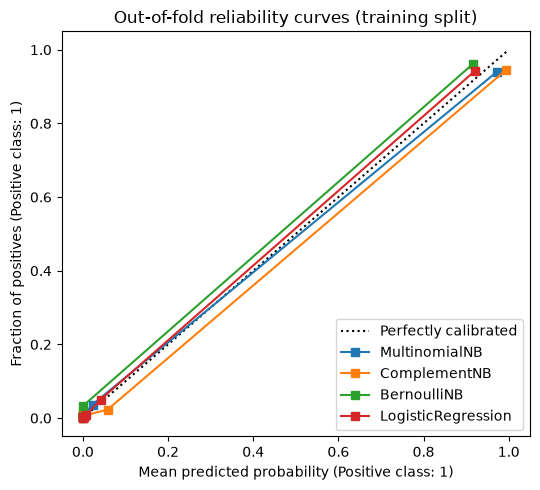

In [40]:
oof = {name: cross_val_predict(search.best_estimator_, text_tr, ys_tr, cv=sms_folds, method="predict_proba")[:, 1]
       for name, search in searches.items()}
for name, p in oof.items():
    cv_summary.loc[name, "OOF Brier"] = brier_score_loss(ys_tr, p)
    cv_summary.loc[name, "OOF log loss"] = log_loss(ys_tr, p)
print(cv_summary[["CV spam F1", "OOF Brier", "OOF log loss"]].round(4))

fig, ax = plt.subplots(figsize=(5.5, 5))
for name, p in oof.items():
    CalibrationDisplay.from_predictions(ys_tr, p, n_bins=8, strategy="quantile", name=name, ax=ax)
ax.set(title="Out-of-fold reliability curves (training split)")
plt.tight_layout()
plt.show()

### Step 4 — Compute the recommendation (from cross-validation only)

The question is "is the best Naive Bayes good enough, or is logistic regression worth it?" Decision rule, stated before looking at the test set:

1. **Accuracy:** the best Naive Bayes model (by CV spam F1) is "good enough" if its F1 is no more than one fold standard deviation below logistic regression's.
2. **Cost:** if it's good enough **and** trains faster, recommend it (cheaper, streamable with `partial_fit`); otherwise recommend logistic regression.
3. **Probabilities:** if the recommended model is Naive Bayes and its out-of-fold log loss is more than 1.5× logistic regression's, recommend wrapping it in `CalibratedClassifierCV` before using its scores. (Log loss punishes overconfidence more strongly than the Brier score.)

In [41]:
nb_names = ["MultinomialNB", "ComplementNB", "BernoulliNB"]
best_nb = cv_summary.loc[nb_names, "CV spam F1"].idxmax()
lr_f1, lr_std = cv_summary.loc["LogisticRegression", "CV spam F1"], cv_summary.loc["LogisticRegression", "F1 std"]
nb_f1 = cv_summary.loc[best_nb, "CV spam F1"]
good_enough = nb_f1 >= lr_f1 - lr_std
speedup = cv_summary.loc["LogisticRegression", "fit ms"] / cv_summary.loc[best_nb, "fit ms"]
recommended = best_nb if (good_enough and speedup > 1) else "LogisticRegression"
logloss_ratio = cv_summary.loc[best_nb, "OOF log loss"] / cv_summary.loc["LogisticRegression", "OOF log loss"]
needs_calibration = recommended in nb_names and logloss_ratio > 1.5

print(f"Best Naive Bayes: {best_nb} (CV F1 {nb_f1:.4f}) vs LogisticRegression (CV F1 {lr_f1:.4f} ± {lr_std:.4f}) "
      f"→ {'good enough' if good_enough else 'clearly worse'}")
print(f"{best_nb} trains {speedup:.1f}× {'faster' if speedup > 1 else 'slower'} than LogisticRegression "
      f"(vectorizer included); its OOF log loss is {logloss_ratio:.1f}× logistic regression's")
print(f"→ RECOMMENDATION: {recommended}"
      + (" wrapped in CalibratedClassifierCV if its probabilities will be used (overconfident scores)" if needs_calibration else ""))

Best Naive Bayes: BernoulliNB (CV F1 0.9456) vs LogisticRegression (CV F1 0.9426 ± 0.0159) → good enough
BernoulliNB trains 5.1× faster than LogisticRegression (vectorizer included); its OOF log loss is 2.1× logistic regression's
→ RECOMMENDATION: BernoulliNB wrapped in CalibratedClassifierCV if its probabilities will be used (overconfident scores)


### Step 5 — The one and only test evaluation

In [42]:
test_rows = {}
for name, search in searches.items():
    model = search.best_estimator_                                     # already refit on the whole training split
    start = time.perf_counter(); p = model.predict_proba(text_te)[:, 1]; predict_ms = (time.perf_counter() - start) * 1000
    pred = (p >= 0.5).astype(int)
    test_rows[name] = {"test spam F1": f1_score(ys_te, pred), "test accuracy": accuracy_score(ys_te, pred),
                       "test Brier": brier_score_loss(ys_te, p), "test log loss": log_loss(ys_te, p), "predict ms": predict_ms}
test_summary = pd.DataFrame(test_rows).T
print(test_summary.round(4))
rec_rank = int(test_summary["test spam F1"].rank(ascending=False)[recommended])
print(f"\nRecommended {recommended}: test F1 {test_summary.loc[recommended, 'test spam F1']:.4f} "
      f"(rank {rec_rank} of {len(test_summary)} on test; the test set confirms, it doesn't re-select)")

                    test spam F1  test accuracy  test Brier  test log loss  \
MultinomialNB             0.9272         0.9816      0.0141         0.0948   
ComplementNB              0.9151         0.9778      0.0175         0.1455   
BernoulliNB               0.9482         0.9874      0.0121         0.0957   
LogisticRegression        0.9323         0.9836      0.0139         0.0565   

                    predict ms  
MultinomialNB           4.4485  
ComplementNB            8.4697  
BernoulliNB             4.3552  
LogisticRegression      8.3325  

Recommended BernoulliNB: test F1 0.9482 (rank 1 of 4 on test; the test set confirms, it doesn't re-select)


### Step 6 — Error analysis for the recommended model

In [43]:
rec_model = searches[recommended].best_estimator_
rec_proba = rec_model.predict_proba(text_te)[:, 1]
errors = sms_test.assign(p_spam=rec_proba, predicted=(rec_proba >= 0.5).astype(int))
false_pos = errors[(errors["predicted"] == 1) & (errors["spam"] == 0)].sort_values("p_spam", ascending=False)
false_neg = errors[(errors["predicted"] == 0) & (errors["spam"] == 1)].sort_values("p_spam")
print(f"{len(false_pos)} false positives (ham flagged as spam), {len(false_neg)} false negatives (spam missed) out of {len(errors)}")
print("\nMost confident false positives:")
for _, r in false_pos.head(3).iterrows():
    print(f"  p={r['p_spam']:.3f} | {r['text'][:100]}")
print("\nMost confidently missed spam:")
for _, r in false_neg.head(3).iterrows():
    print(f"  p={r['p_spam']:.3f} | {r['text'][:100]}")

1 false positives (ham flagged as spam), 12 false negatives (spam missed) out of 1035

Most confident false positives:
  p=0.969 | Plz note: if anyone calling from a mobile Co. &amp; asks u to type # &lt;#&gt;  or # &lt;#&gt; . Do 

Most confidently missed spam:
  p=0.000 | In The Simpsons Movie released in July 2007 name the band that died at the start of the film? A-Gree
  p=0.000 | Babe: U want me dont u baby! Im nasty and have a thing 4 filthyguys. Fancy a rude time with a sexy b
  p=0.000 | Missed call alert. These numbers called but left no message. 07008009200


### Step 7 — Conclusions (computed)

In [44]:
fastest_fit = cv_summary["fit ms"].idxmin()
best_calibrated = cv_summary["OOF Brier"].idxmin()
print(f"1. CV ranking by spam F1: {', '.join(cv_summary.index)}; the spread is "
      f"{cv_summary['CV spam F1'].max() - cv_summary['CV spam F1'].min():.3f}.")
print(f"2. Recommendation: {recommended}. Test F1 {test_summary.loc[recommended, 'test spam F1']:.3f} vs its CV F1 "
      f"{cv_summary.loc[recommended, 'CV spam F1']:.3f} → "
      f"{'consistent' if abs(test_summary.loc[recommended, 'test spam F1'] - cv_summary.loc[recommended, 'CV spam F1']) < 0.03 else 'a noticeable gap (small test set: ~150 spam messages)'}.")
print(f"3. Fastest to train: {fastest_fit} ({cv_summary.loc[fastest_fit, 'fit ms']:.0f} ms per fold, vectorizer included); "
      f"best calibrated out-of-fold: {best_calibrated} (Brier {cv_summary.loc[best_calibrated, 'OOF Brier']:.4f}).")
print(f"4. Errors on {len(errors):,} test messages: {len(false_pos)} ham flagged as spam, {len(false_neg)} spam missed. "
      f"For a phone inbox false positives are costlier, so tune the threshold on out-of-fold probabilities for a target precision.")
print(f"5. Probabilities: {'calibrate before using scores' if needs_calibration else 'no calibration step required by the rule'} "
      f"(best NB OOF log loss {cv_summary.loc[best_nb, 'OOF log loss']:.3f} vs logistic regression "
      f"{cv_summary.loc['LogisticRegression', 'OOF log loss']:.3f}).")

1. CV ranking by spam F1: BernoulliNB, MultinomialNB, LogisticRegression, ComplementNB; the spread is 0.010.
2. Recommendation: BernoulliNB. Test F1 0.948 vs its CV F1 0.946 → consistent.
3. Fastest to train: MultinomialNB (17 ms per fold, vectorizer included); best calibrated out-of-fold: BernoulliNB (Brier 0.0120).
4. Errors on 1,035 test messages: 1 ham flagged as spam, 12 spam missed. For a phone inbox false positives are costlier, so tune the threshold on out-of-fold probabilities for a target precision.
5. Probabilities: calibrate before using scores (best NB OOF log loss 0.106 vs logistic regression 0.050).


**Stretch goals**
1. Tune the decision threshold with `TunedThresholdClassifierCV` for **precision ≥ 0.99** (losing a real message is worse than seeing a spam) and compare recall.
2. Calibrate the best Naive Bayes model with `CalibratedClassifierCV(method="isotonic")` and re-draw the reliability curves.
3. Add character n-grams (`CountVectorizer(analyzer="char_wb", ngram_range=(2, 5))`) to catch obfuscations like "fr33".
4. Simulate a stream: train with `partial_fit` + `HashingVectorizer` in batches of 200 messages and plot test F1 as messages arrive.

### 🗣️ How to talk about this in an interview
- "I de-duplicated the SMS collection first, because hundreds of repeated messages would otherwise leak across the train/test split."
- "Every choice, from n-grams and α/C to the model itself, was made with 5-fold CV on the training split with the vectorizer inside the pipeline; the test set was scored once to confirm."
- "I compared Multinomial, Complement and Bernoulli NB with logistic regression on F1, calibration (out-of-fold Brier and reliability curves) and training/prediction time, and wrote the decision rule down before looking at test results."
- "Naive Bayes trains in milliseconds and supports `partial_fit`, but its probabilities are overconfident, so if we use scores for thresholds or risk I'd calibrate them."
- "Next steps: a precision-constrained threshold, character n-grams for obfuscated spam, and monitoring for drift as spammers change wording."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. Why is Naive Bayes called "naive"?**

<details><summary>Show answer</summary>

- **30-second answer:** It assumes all features are conditionally independent given the class, so $P(x_1,\dots,x_d \mid y) = \prod_j P(x_j \mid y)$. That's rarely true (words co-occur, measurements correlate), but it makes the model need only one simple distribution per feature and class.
- **Go deeper:** Without the assumption, the joint distribution of d binary features needs $2^d - 1$ parameters per class; with it, d. That's why it trains by counting and needs little data. The cost is double-counted evidence and overconfident posteriors.
- **❌ Common wrong answer:** "It assumes the features are independent of each other" (unconditionally) or "it assumes the classes are independent."

</details>

**Q2. What's the difference between generative and discriminative classifiers? Where does Naive Bayes fit?**

<details><summary>Show answer</summary>

- **30-second answer:** Generative models learn $P(x \mid y)$ and $P(y)$ and use Bayes' rule to get $P(y \mid x)$; Naive Bayes, LDA and GMM classifiers are generative. Discriminative models such as logistic regression and SVMs learn $P(y \mid x)$ or the boundary directly.
- **Go deeper:** Ng & Jordan (2001) showed NB converges to its asymptotic error with O(log d) samples vs O(d) for logistic regression, but LR's asymptotic error is lower. So NB tends to win with small data and LR with more. Multinomial/Bernoulli NB and LR even share the same linear form in log space; they just fit the weights differently.
- **❌ Common wrong answer:** "Generative means it can generate text like an LLM, so it's more powerful."

</details>

**Q3. The independence assumption is clearly violated. Why does Naive Bayes still classify well?**

<details><summary>Show answer</summary>

- **30-second answer:** Classification only needs the correct class to have the highest score, not correct probabilities. Violations often inflate all classes' scores in a similar direction, so the argmax survives, and NB's low variance helps with small data.
- **Go deeper:** Domingos & Pazzani (1997) proved NB can be optimal under 0-1 loss even with strong dependence. We showed it: 8 duplicated copies of the breast-cancer features lowered accuracy and AUC only slightly but multiplied log loss about four times. So probabilities are overconfident; use it for ranking/argmax and calibrate if you need probabilities.
- **❌ Common wrong answer:** "Because the features in real data are usually independent."

</details>

**Q4. What is Laplace smoothing, and what happens without it?**

<details><summary>Show answer</summary>

- **30-second answer:** Add α pseudo-counts to every feature in every class: $\hat\theta_{cj} = (N_{cj}+\alpha)/(N_c+\alpha d)$. Without it, a word never seen in a class has probability 0, which zeroes the whole product (−∞ in log space) no matter how strong the other evidence is.
- **Go deeper:** α = 1 is Laplace, 0 < α < 1 Lidstone; it's the posterior mean under a symmetric Dirichlet prior. In our SMS demo, α = 0 left some test messages with −∞ for both classes (an undefined posterior). Tune α on a log scale by CV; too large dilutes informative words. scikit-learn clips α below 1e-10 unless `force_alpha=True`.
- **❌ Common wrong answer:** "Smoothing is only needed for words in the test set that aren't in the vocabulary." Out-of-vocabulary words are simply ignored; smoothing handles vocabulary words unseen *in a particular class*.

</details>

**Q5. Gaussian, Multinomial, Bernoulli, Complement, Categorical: which one when?**

<details><summary>Show answer</summary>

- **30-second answer:** Gaussian for continuous features; Multinomial for counts or TF-IDF (text); Bernoulli for binary presence/absence features and short texts; Complement for text with imbalanced classes; Categorical for nominal features encoded as integer codes.
- **Go deeper:** Bernoulli penalizes absent words, Multinomial ignores them. Complement estimates from all other classes, so rare classes get stable weights (on our imbalanced newsgroups it far outscored Multinomial on macro-F1). Categorical needs `min_categories` for levels unseen in training. Mixed data: fit separate NBs per feature type and add their log-likelihoods (subtracting the duplicated log prior).
- **❌ Common wrong answer:** "Use GaussianNB for everything after scaling."

</details>

**Q6. Why do implementations work with log-probabilities?**

<details><summary>Show answer</summary>

- **30-second answer:** Multiplying hundreds of probabilities underflows to 0.0 in float64, making every class tie. Summing log-probabilities is numerically safe and preserves the argmax; posteriors are recovered with the log-sum-exp trick.
- **Go deeper:** In log space prediction is $\log P(c) + x\cdot\log\theta_c$, a sparse dot product: fast for text. scikit-learn exposes `feature_log_prob_`, `class_log_prior_`, `predict_joint_log_proba` and `predict_log_proba`.
- **❌ Common wrong answer:** "Logs make the model more accurate" — the argmax is identical; logs fix numerical stability.

</details>

**Q7. Is Naive Bayes a linear classifier?**

<details><summary>Show answer</summary>

- **30-second answer:** Multinomial and Bernoulli NB are linear in the (binary/count) features in log space: the score is $w_c \cdot x + b_c$. Gaussian NB is quadratic in general because each class has its own variances; with shared variances it becomes linear.
- **Go deeper:** For binary problems the log-odds $\log\frac{P(1\mid x)}{P(0\mid x)}$ is exactly linear for Multinomial/Bernoulli NB, the same functional form as logistic regression; the difference is how weights are estimated (counting under an independence assumption vs maximizing conditional likelihood).
- **❌ Common wrong answer:** "It's non-linear because it uses probabilities."

</details>

**Q8. Are Naive Bayes probabilities calibrated? How do you fix them?**

<details><summary>Show answer</summary>

- **30-second answer:** Usually not: they are pushed towards 0 and 1 (overconfident) because correlated evidence is multiplied as if independent. Check with a reliability curve, Brier score and log loss on held-out data, and fix with `CalibratedClassifierCV` (sigmoid/Platt or isotonic) fitted on data the model didn't train on.
- **Go deeper:** Niculescu-Mizil & Caruana (2005) found NB among the worst-calibrated models and that calibration helps it a lot. Calibration is monotonic, so AUC barely changes. Isotonic needs more data than sigmoid. Use cross-validation (`cv=5`) or a separate calibration split with `FrozenEstimator`.
- **❌ Common wrong answer:** "It's a probabilistic model, so its probabilities are accurate by construction."

</details>

**Q9. How does Naive Bayes deal with a word it never saw during training, or a missing feature value?**

<details><summary>Show answer</summary>

- **30-second answer:** A word outside the vocabulary has no column, so it's ignored. A vocabulary word unseen in one class gets the smoothed probability. A missing feature can be dropped from the product for that sample (marginalized out), a nice NB property, although scikit-learn doesn't do it automatically, so impute or add a "missing" category.
- **Go deeper:** Because the likelihood factorizes, marginalizing a missing feature just removes its term, which is exact under the model. `HashingVectorizer` avoids a fixed vocabulary altogether for streaming.
- **❌ Common wrong answer:** "It crashes on unseen words" or "the whole message gets probability 0."

</details>

### 💻 Coding

**Q10. Implement Multinomial Naive Bayes `fit` and `predict` in NumPy.**

<details><summary>Show answer</summary>

- **30-second answer:**
  ```python
  classes = np.unique(y)
  log_prior = np.log(np.array([(y == c).mean() for c in classes]))
  counts = np.stack([X[y == c].sum(0) for c in classes]) + alpha
  log_theta = np.log(counts / counts.sum(1, keepdims=True))
  pred = classes[(X @ log_theta.T + log_prior).argmax(1)]
  ```
- **Go deeper:** Normalize with log-sum-exp for `predict_log_proba`; keep X sparse; mention O(nnz) training and prediction. Our notebook's Complement NB exercise and the Classical NLP notebook's `ScratchMultinomialNB` match scikit-learn exactly.
- **❌ Common wrong answer:** Multiplying raw probabilities (underflow), forgetting smoothing, or smoothing with `+alpha` in the numerator but not `+alpha·d` in the denominator (rows no longer sum to 1).

</details>

**Q11. How do you train Naive Bayes on data that doesn't fit in memory?**

<details><summary>Show answer</summary>

- **30-second answer:** Stream mini-batches into `partial_fit` (passing `classes` on the first call) with a stateless `HashingVectorizer(alternate_sign=False)`. Since the sufficient statistics are counts, the final model equals a single fit on all the data, as we asserted.
- **Go deeper:** Counts from different workers can simply be summed (map-reduce, Spark MLlib), and you can decay old counts to adapt to drift. `GaussianNB.partial_fit` updates running means and variances incrementally.
- **❌ Common wrong answer:** "Call `fit` on each batch" — every `fit` call starts over and forgets the previous batches.

</details>

### 🐛 Debugging Scenarios

**Q12. A message full of obvious spam words gets P(spam) = 0.0 from your hand-rolled Naive Bayes. What's wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** A zero-frequency problem: some word in the message never appeared in training spam and there's no smoothing, so its probability is 0 and wipes out the product. Add Laplace/Lidstone smoothing (α > 0) and compute in log space.
- **Go deeper:** Also check for underflow (multiplying raw probabilities of a long message gives 0 for every class) and for a vocabulary mismatch between training and prediction (vectorizer refit on new data). Unit-test against `MultinomialNB`.
- **❌ Common wrong answer:** "Naive Bayes can't handle long messages" or "remove the unknown words from the training data."

</details>

**Q13. `MultinomialNB` raises "Negative values in data passed to MultinomialNB". What happened?**

<details><summary>Show answer</summary>

- **30-second answer:** Someone put a `StandardScaler` (or another centring step, or signed hashing) in front of it. Multinomial/Complement NB model counts, which must be non-negative. Remove the scaler, use counts/TF-IDF, `HashingVectorizer(alternate_sign=False)`, `MinMaxScaler`, or switch to `GaussianNB` for continuous features.
- **Go deeper:** Default `HashingVectorizer` uses `alternate_sign=True`, producing negative values: a common source of this error in streaming pipelines.
- **❌ Common wrong answer:** "Take the absolute value of the features."

</details>

**Q14. After adding engineered features that are combinations of existing ones, your Naive Bayes model's accuracy is unchanged but its predicted probabilities are almost all 0 or 1, and log loss doubled. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** The new features are strongly correlated with the old ones, so the same evidence is multiplied in several times. The argmax barely changes, but posteriors become extreme. Remove redundant features, or calibrate the probabilities.
- **Go deeper:** Exactly our duplicated-features experiment. Feature selection (e.g. drop features with |r| > 0.95), PCA whitening for Gaussian NB, or a discriminative model all help; monitor log loss/Brier, not just accuracy.
- **❌ Common wrong answer:** "More features always give Naive Bayes more information."

</details>

### 🏗️ Design

**Q15. Design a spam filter for a large email or messaging service.**

<details><summary>Show answer</summary>

- **30-second answer:** Start with a fast baseline (Naive Bayes or logistic regression on hashed word and character n-grams plus metadata features like sender reputation and links), trained on user reports, updated continuously, and evaluated by precision at a fixed false-positive rate, because losing a real message is costly. Graduate to gradient boosting or a small transformer if the metrics justify the cost.
- **Go deeper:** Streaming updates with `partial_fit`/online learning to follow adversarial drift; de-duplication and time-based splits to avoid leakage; calibrated scores with thresholds per action (spam folder vs block vs warn); per-user personalization via user-level priors; latency budget per message; monitoring of report rates and drift; defences against poisoning (rate-limit report weight, trust signals); privacy constraints on content.
- **❌ Common wrong answer:** "Train the most accurate deep model once on a random split and maximize accuracy."

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal. (Every answer was verified by running it with the versions in the header.)

**1.** 20% of messages are spam, 60% of spam contains "win", 5% of ham contains "win". What is $P(\text{spam} \mid \text{"win"})$?
<details><summary>Answer</summary>

**0.75** — $\frac{0.6 \times 0.2}{0.6 \times 0.2 + 0.05 \times 0.8} = \frac{0.12}{0.16}$.
</details>

**2.** A class has word counts `[3, 0, 1]` over a 3-word vocabulary. With `MultinomialNB(alpha=1)`, what is $P(\text{word}_1 \mid \text{class})$ (the middle word)?
<details><summary>Answer</summary>

**1/7 ≈ 0.143** — $(0 + 1) / (4 + 3)$.
</details>

**3.** What does `np.prod(np.full(400, 1e-3))` return?
<details><summary>Answer</summary>

`0.0` — the true value $10^{-1200}$ underflows float64. `np.log(np.full(400, 1e-3)).sum()` is about `-2763.1`, no problem.
</details>

**4.** What happens with `MultinomialNB().fit(StandardScaler().fit_transform(X), y)`?
<details><summary>Answer</summary>

`ValueError: Negative values in data passed to MultinomialNB (input X)` — standardized features are negative; counts can't be.
</details>

**5.** `GaussianNB().fit([[0], [1], [10], [11]], [0, 0, 1, 1]).predict([[5.4]])`
<details><summary>Answer</summary>

`array([0])` — both classes have the same variance (0.25), so the boundary is halfway between the means 0.5 and 10.5, at 5.5.
</details>

## 📚 Resources

### 📖 Official Docs
- [scikit-learn — Naive Bayes user guide](https://scikit-learn.org/stable/modules/naive_bayes.html) — all five variants with their exact formulas
- [scikit-learn — ComplementNB API](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.ComplementNB.html) — `norm`, `alpha`, and the imbalanced-text motivation
- [scikit-learn — Probability calibration](https://scikit-learn.org/stable/modules/calibration.html) · [Comparison of Calibration of Classifiers](https://scikit-learn.org/stable/auto_examples/calibration/plot_compare_calibration.html) — reliability curves, including Gaussian NB
- [scikit-learn — CalibratedClassifierCV API](https://scikit-learn.org/stable/modules/generated/sklearn.calibration.CalibratedClassifierCV.html) — `method`, `cv`, `ensemble`, and `FrozenEstimator`
- [scikit-learn — Strategies to scale computationally](https://scikit-learn.org/stable/computing/scaling_strategies.html) · [HashingVectorizer API](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.HashingVectorizer.html) — `partial_fit` and out-of-core text learning

### 🎥 Videos
- [StatQuest (Josh Starmer) — Naive Bayes, Clearly Explained!!!](https://www.youtube.com/watch?v=O2L2Uv9pdDA) (~15 min) — the spam example, priors, likelihoods and why it's "naive"; watch before Section 2
- [StatQuest (Josh Starmer) — Gaussian Naive Bayes, Clearly Explained!!!](https://www.youtube.com/watch?v=H3EjCKtlVog) (~9 min) — continuous features, bell curves per class and log-probabilities; pairs with Sections 3–4
- [3Blue1Brown — Bayes theorem, the geometry of changing beliefs](https://www.youtube.com/watch?v=HZGCoVF3YvM) (~15 min) — the best visual intuition for priors and base rates (Section 1)

### 📄 Papers
- [Domingos & Pazzani (1997) — On the Optimality of the Simple Bayesian Classifier under Zero-One Loss](https://link.springer.com/article/10.1023/A:1007413511361) — why NB classifies well despite dependent features
- [Ng & Jordan (2001) — On Discriminative vs. Generative Classifiers: A comparison of logistic regression and naive Bayes](https://proceedings.neurips.cc/paper/2001/hash/7b7a53e239400a13bd6be6c91c4f6c4e-Abstract.html) — the two regimes of Q2
- [Rennie, Shih, Teevan & Karger (2003) — Tackling the Poor Assumptions of Naive Bayes Text Classifiers (PDF)](https://cdn.aaai.org/ICML/2003/ICML03-081.pdf) — Complement NB and other fixes
- [Niculescu-Mizil & Caruana (2005) — Predicting Good Probabilities With Supervised Learning (PDF)](https://www.cs.cornell.edu/~alexn/papers/calibration.icml05.crc.rev3.pdf) — NB's overconfidence and how Platt/isotonic calibration fix it

### 📘 Books & Courses
- [Manning, Raghavan & Schütze — Introduction to Information Retrieval: Naive Bayes text classification](https://nlp.stanford.edu/IR-book/html/htmledition/naive-bayes-text-classification-1.html) — multinomial vs Bernoulli models, free online
- [Jurafsky & Martin — Speech and Language Processing](https://web.stanford.edu/~jurafsky/slp3/) — the free draft's chapter on Naive Bayes and sentiment classification
- [Cornell CS4780 — Lecture 5: Bayes Classifier and Naive Bayes](https://www.cs.cornell.edu/courses/cs4780/2018fa/lectures/lecturenote05.html) — derivations and the linear-classifier connection

### 🏋️ Practice
- [Kaggle — SMS Spam Collection Dataset](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset) — the mini project's data, with many community notebooks to compare against

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Bayes' theorem | flip likelihood into posterior | $P(y\mid x) = P(x\mid y)P(y)/P(x)$ |
| Naive assumption | features independent given the class | $P(x\mid y) = \prod_j P(x_j\mid y)$ |
| Log space | avoid underflow, same argmax | $\ell_c = \log P(c) + \sum_j \log P(x_j\mid c)$; `logsumexp`; `predict_log_proba` |
| Gaussian NB | continuous features | `GaussianNB(var_smoothing=...)`; `theta_`, `var_` |
| Multinomial NB | counts / TF-IDF | `MultinomialNB(alpha)`; $\hat\theta_{cj} = \frac{N_{cj}+\alpha}{N_c+\alpha d}$ |
| Smoothing | fixes zero frequencies | α = 1 Laplace, 0 < α < 1 Lidstone; tune on log scale |
| Bernoulli NB | binary presence, absent words count | `BernoulliNB(alpha, binarize)`; $\frac{n_{cj}+\alpha}{n_c+2\alpha}$ |
| Complement NB | imbalanced text | `ComplementNB(alpha, norm)`; estimate from all other classes |
| Categorical NB | nominal features | `OrdinalEncoder` + `CategoricalNB(min_categories=...)` |
| Overconfidence | correlated evidence double-counted | good accuracy/AUC, poor log loss/Brier |
| Calibration | trustworthy probabilities | `CalibratedClassifierCV(method="sigmoid"/"isotonic", cv=5)`, `FrozenEstimator`, `CalibrationDisplay` |
| Streaming | learn batch by batch | `partial_fit(X, y, classes=...)` + `HashingVectorizer(alternate_sign=False)` |

## ➡️ What's Next

**[07 · Support Vector Machines](07_Support_Vector_Machines.ipynb)** — Naive Bayes set its linear text weights by counting; SVMs choose them by maximizing the margin between classes, and the kernel trick bends that boundary into curves. On the same text data they are often the strongest classical model.